# GLM-HMM Ver.4 学習B（顔つき13次元、全日）

`notebooks/14_glmhmm_ver4_trials.ipynb` の学習B（顔つき13次元モデル）だけを取り出し、追加取得したNWB（対象個体の全task-day分）向けに拡張したノート。学習A（行動4次元）との比較は行わず、学習Bのみを対象とする。

- 状態数はK=3固定（K=2との比較はしない）
- HMMは**日ごとに独立して学習**する（日をまたぐ状態遷移・パラメータ共有はしない）
- 対象個体の全task-dayについて、最初から通しで学習・可視化する
- 4次元モデルとのLL比較は行わない

## 実装上の既定値

ノート14の学習Bと同じ既定値を使う。

| 項目 | 既定 |
| :--- | :--- |
| $\alpha_{act}$ | 0.65 |
| $\alpha_{rew}$ | 0.80 |
| 正則化 | MAP `prior_sigma=2.0` |
| 状態数 | K=3 固定 |
| 学習 | `seeds=[0,1,2]`、`num_iters=200`、各seedのうちベストLLを採用 |
| 顔特徴 | 9次元（耳・目・鼻・顎の位置/速度、瞳孔）。試行ウィンドウ内で位置/瞳孔は中央値・速度は平均、セッション内z-score後に1試行ラグ |

NWBが無い、または顔特徴が取得できない日は学習をスキップする。

In [1]:
# ===================================================================
# 共通セットアップセル (ローカル / Colab 共通)
# ===================================================================
import sys
import os
from pathlib import Path

# --- 1. 環境判別 ---
IN_COLAB = False
try:
    # Colab環境でのみインポートが成功する
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass # ローカル環境


if IN_COLAB:
    # ==================================
    # Colab 環境でのセットアップ
    # ==================================
    print("環境: Colab を検出。セットアップを開始します。")

    # 1. Google Driveのマウント
    drive.mount('/content/drive')

    # 2. GitHubリポジトリのクローンまたはプル
    repo_path = Path('/content/braidyn-bc')
    if repo_path.exists():
        print("リポジトリを pull します...")
        os.chdir(repo_path)
        !git pull
    else:
        print("リポジトリを clone します...")
        !git clone https://github.com/nyaamikeneko/braidyn-bc.git
        os.chdir(repo_path)

    # 3. 依存ライブラリのインストール
    print("依存ライブラリをインストールします...")
    !pip install -q pynwb git+https://github.com/BraiDyn-BC/bdbc-nwb-explorer.git

    # 4. sys.path の設定
    project_root = repo_path
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"セットアップ完了。プロジェクトルート: {project_root}")

else:
    # ==================================
    # ローカル (VSCode) 環境でのセットアップ
    # ==================================
    print("環境: ローカル (VSCode) を検出。")

    # 1. sys.path の設定
    current_dir = Path.cwd()
    if current_dir.name == 'notebooks':
        # ノートブックが notebooks/ から実行された場合
        project_root = current_dir.parent
    else:
        # プロジェクトルート (braidyn-bc/) から実行されたと仮定
        project_root = current_dir

    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"プロジェクトルート: {project_root}")

# ===================================================================
# 共通インポート・処理
# (セットアップが完了したため、config.py や src/ が読み込める)
# ===================================================================
print("\n共通モジュールをインポートします...")

import bdbc_nwb_explorer as nwbx
import src.data_loader as dl
import config  # config.py もここで読み込める

print(f"データパス (DATA_NWB_ROOT): {config.DATA_NWB_ROOT}")
print(f"データパス (DATA_CSV_ROOT): {config.DATA_CSV_ROOT}")

環境: ローカル (VSCode) を検出。
プロジェクトルート: /mnt/c/Users/dmasu/braidyn-bc

共通モジュールをインポートします...


環境: ローカル (WSL)
DATA_CSV_ROOT: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data
データパス (DATA_NWB_ROOT): /mnt/g/マイドライブ/nwb_manual
データパス (DATA_CSV_ROOT): /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data


In [2]:
# ssm（lindermanlab）が無ければ入れる。Windows ではビルドに失敗することがある。
try:
    import ssm
    print("ssm:", ssm.__file__)
except ImportError:
    print("ssm が見つからないのでインストールを試みます...")
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "-q", "cython"])
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/lindermanlab/ssm"])
    import ssm
    print("ssm installed:", ssm.__file__)

ssm: /mnt/c/Users/dmasu/braidyn-bc/.venv-wsl/lib/python3.12/site-packages/ssm/__init__.py


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.glmhmm_ver4 as v4

# これはColabの/content/drive配下のパスなので、ローカル(Windows/WSL)では使わない
# （config.pyのローカル分岐がすでにG:マイドライブ/nwb_manualを見に行く）。
NWB_ROOT_OVERRIDE = "/content/drive/MyDrive/nwb_manual" if IN_COLAB else None
if NWB_ROOT_OVERRIDE:
    config.DATA_NWB_ROOT = Path(NWB_ROOT_OVERRIDE)
print("NWB探索先 (DATA_NWB_ROOT):", config.DATA_NWB_ROOT)

MOUSE_ID = "VG1GC-66"
NUM_STATES_B = 3   # 学習B(13次元)の状態数。今回はK=3固定（K=2との比較はしない）
ALPHA_ACT = v4.ALPHA_ACT     # 0.65
ALPHA_REW = v4.ALPHA_REW     # 0.80
PRIOR_SIGMA = v4.PRIOR_SIGMA
SEEDS = [0, 1, 2]
NUM_ITERS = 200

FACE_NAMES = [
    "Bias", "Stimulus", "Act Hist", "Rew Hist",
    "Ear Pos", "Ear Spd", "Eye Pos", "Eye Spd",
    "Nose Pos", "Nose Spd", "Jaw Pos", "Jaw Spd",
    "Pupil",
]

print(f"mouse={MOUSE_ID}  13-dim K={NUM_STATES_B}  alpha_act={ALPHA_ACT}  alpha_rew={ALPHA_REW}")
print("available days:", v4.list_task_days(MOUSE_ID))

NWB探索先 (DATA_NWB_ROOT): /mnt/g/マイドライブ/nwb_manual
mouse=VG1GC-66  13-dim K=3  alpha_act=0.65  alpha_rew=0.8


available days: ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']


## 1. 個体の全日を系列化

各`task-day`をssm用の1系列にする（ITIカットなし）。`process_mouse`は4次元・13次元両方の配列を作るが、本ノートでは13次元（`xs13`）のみ使う。顔特徴が取れないセッションはこの後の学習ループでスキップする。

In [4]:
dataset = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)
print("\n=== all days ===")
print("n sequences:", len(dataset["ys"]))
print("n trials:", len(dataset["trials"]))
print("sessions with face:", dataset["n_with_face"], "/", len(dataset["ys"]))

face_idx = [i for i, s in enumerate(dataset["sessions"]) if s["has_face"]]
skipped_days = [d for i, d in enumerate(dataset["task_days"]) if i not in face_idx]
print("学習対象日 (顔特徴あり):", [dataset["task_days"][i] for i in face_idx])
if skipped_days:
    print("スキップ対象 (顔特徴なし):", skipped_days)

CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day1/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-21_task-day1.nwb


VG1GC-66 task-day1: 787 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day3/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-23_task-day3.nwb


VG1GC-66 task-day3: 548 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day4/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-24_task-day4.nwb


VG1GC-66 task-day4: 470 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day5/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-25_task-day5.nwb


VG1GC-66 task-day5: 376 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day6/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-28_task-day6.nwb


...

VG1GC-66 task-day12: 393 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day13/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-09-06_task-day13.nwb


VG1GC-66 task-day13: 509 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day14/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-09-07_task-day14.nwb


VG1GC-66 task-day14: 393 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day15/trials_L1L2.csv
全試行数: 54000


NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-09-08_task-day15.nwb


VG1GC-66 task-day15: 498 trials, face=yes

=== all days ===
n sequences: 14
n trials: 6745
sessions with face: 14 / 14
学習対象日 (顔特徴あり): ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']


## 2. 全日概観: trial type内訳とpull durationの推移

学習ループに入る前に、全日を通した傾向を確認する。

- 日ごとのtrial type内訳（積み上げ棒）
- 刺激タイプ（Success / Short Pull / Second Pull / No Sound Pull）別のpull duration（レバー保持時間。`t_onset`から実際に解放されるまでの実測で、`t_start`/`t_end`は使わない — Success/Short Pullでは音提示ウィンドウ全体を含んでしまうため）の日変化。No Reactionはpullが無いため対象外。

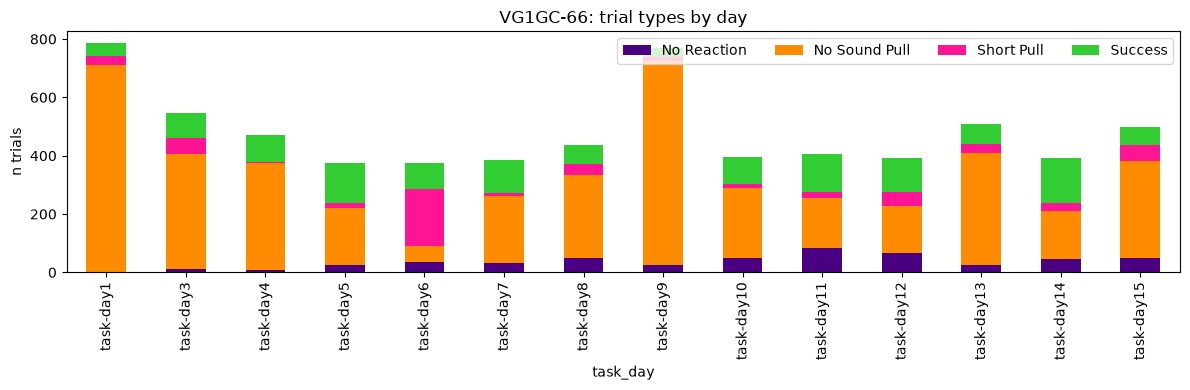

In [5]:
counts = (
    dataset["trials"]
    .groupby(["task_day", "trial_type"])
    .size()
    .unstack(fill_value=0)
)
day_order = dataset["task_days"]
counts = counts.reindex(day_order)
ax = counts.plot(kind="bar", stacked=True, figsize=(12, 4), color=[v4.TRIAL_TYPE_COLORS.get(c, "gray") for c in counts.columns])
ax.set_ylabel("n trials")
ax.set_title(f"{MOUSE_ID}: trial types by day")
ax.legend(ncol=5, loc="upper right")
plt.tight_layout()
plt.show()

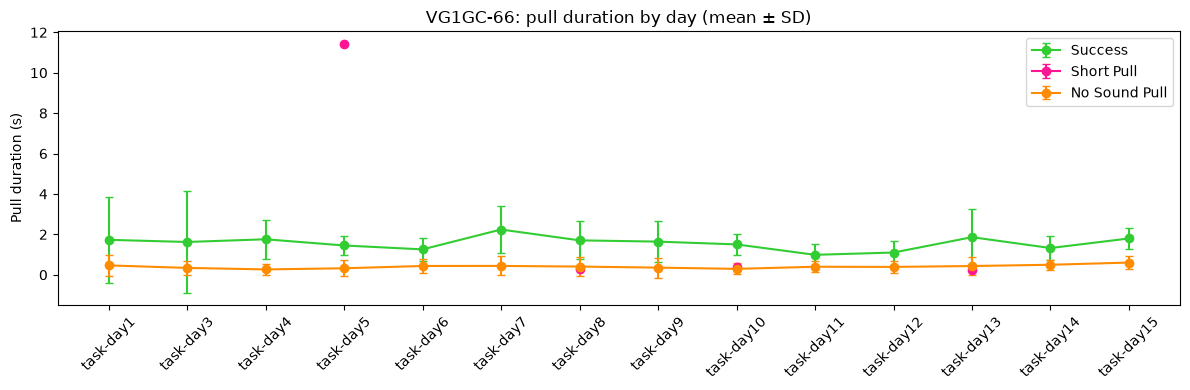

In [6]:
pull_rows = []
for s in dataset["sessions"]:
    day = s["trials"]["task_day"].iloc[0]
    df = s["trials"][["trial_type"]].copy()
    df["task_day"] = day
    df["pull_duration"] = v4.compute_pull_durations(s["trials"], s["cleaned"])
    pull_rows.append(df)
pull_df = pd.concat(pull_rows, ignore_index=True)
pull_df = pull_df[pull_df["trial_type"] != "No Reaction"].dropna(subset=["pull_duration"])

summary = pull_df.groupby(["task_day", "trial_type"])["pull_duration"].agg(["mean", "std", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
for ttype in ["Success", "Short Pull", "Second Pull", "No Sound Pull"]:
    sub = summary[summary["trial_type"] == ttype].set_index("task_day").reindex(day_order)
    if sub["mean"].notna().any():
        ax.errorbar(
            day_order, sub["mean"], yerr=sub["std"],
            marker="o", color=v4.TRIAL_TYPE_COLORS[ttype], label=ttype, capsize=3,
        )
ax.set_ylabel("Pull duration (s)")
ax.set_title(f"{MOUSE_ID}: pull duration by day (mean ± SD)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. 学習B: 顔つき13次元を日ごとに独立学習（K=3固定）+ 可視化

顔特徴のある各日について、K=3のGLM-HMMを学習したうえで、trial type・stimulus・action history・reward history・state posterior・Viterbi pathを試行インデックスを共有軸とする1枚のパネル図にまとめて可視化する。GLM重み・遷移行列・状態別の行動サマリー（action probability・trial-type mix）は別図で確認する。

trial typeはtrial_index位置の色分け（No Reactionはindigo）、stimulusは`x_stim=1`の区間のみを青塗りする（actionの重ね描きはしない。action/outcomeの区別はtrial typeパネル側で表現する）。

Viterbi占有数が0の状態は、その日は実質的に使われていない（縮退している）ことを示す。


task-day1 (n=787 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-65.69


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-64.23


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-64.23
Best log_prob=-64.23


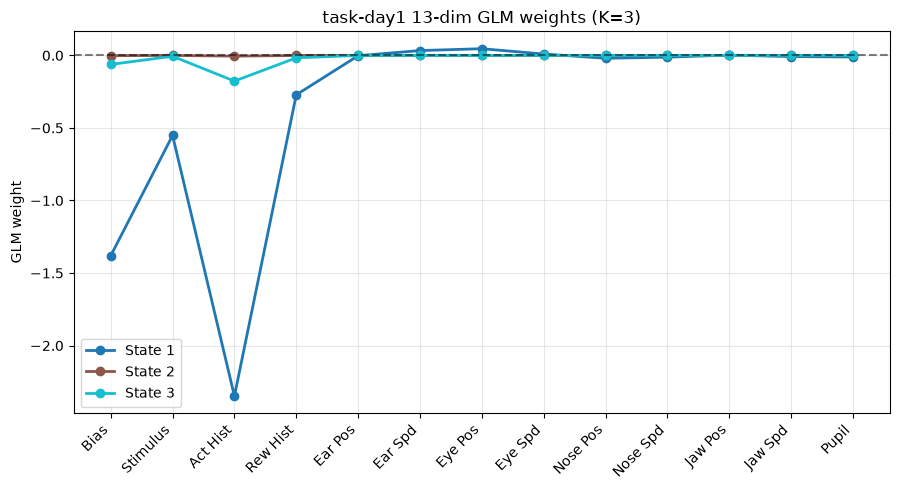

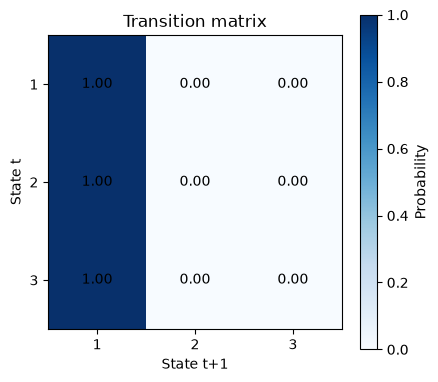

[[1.    0.    0.   ]
 [1.    0.    0.   ]
 [0.999 0.    0.001]]


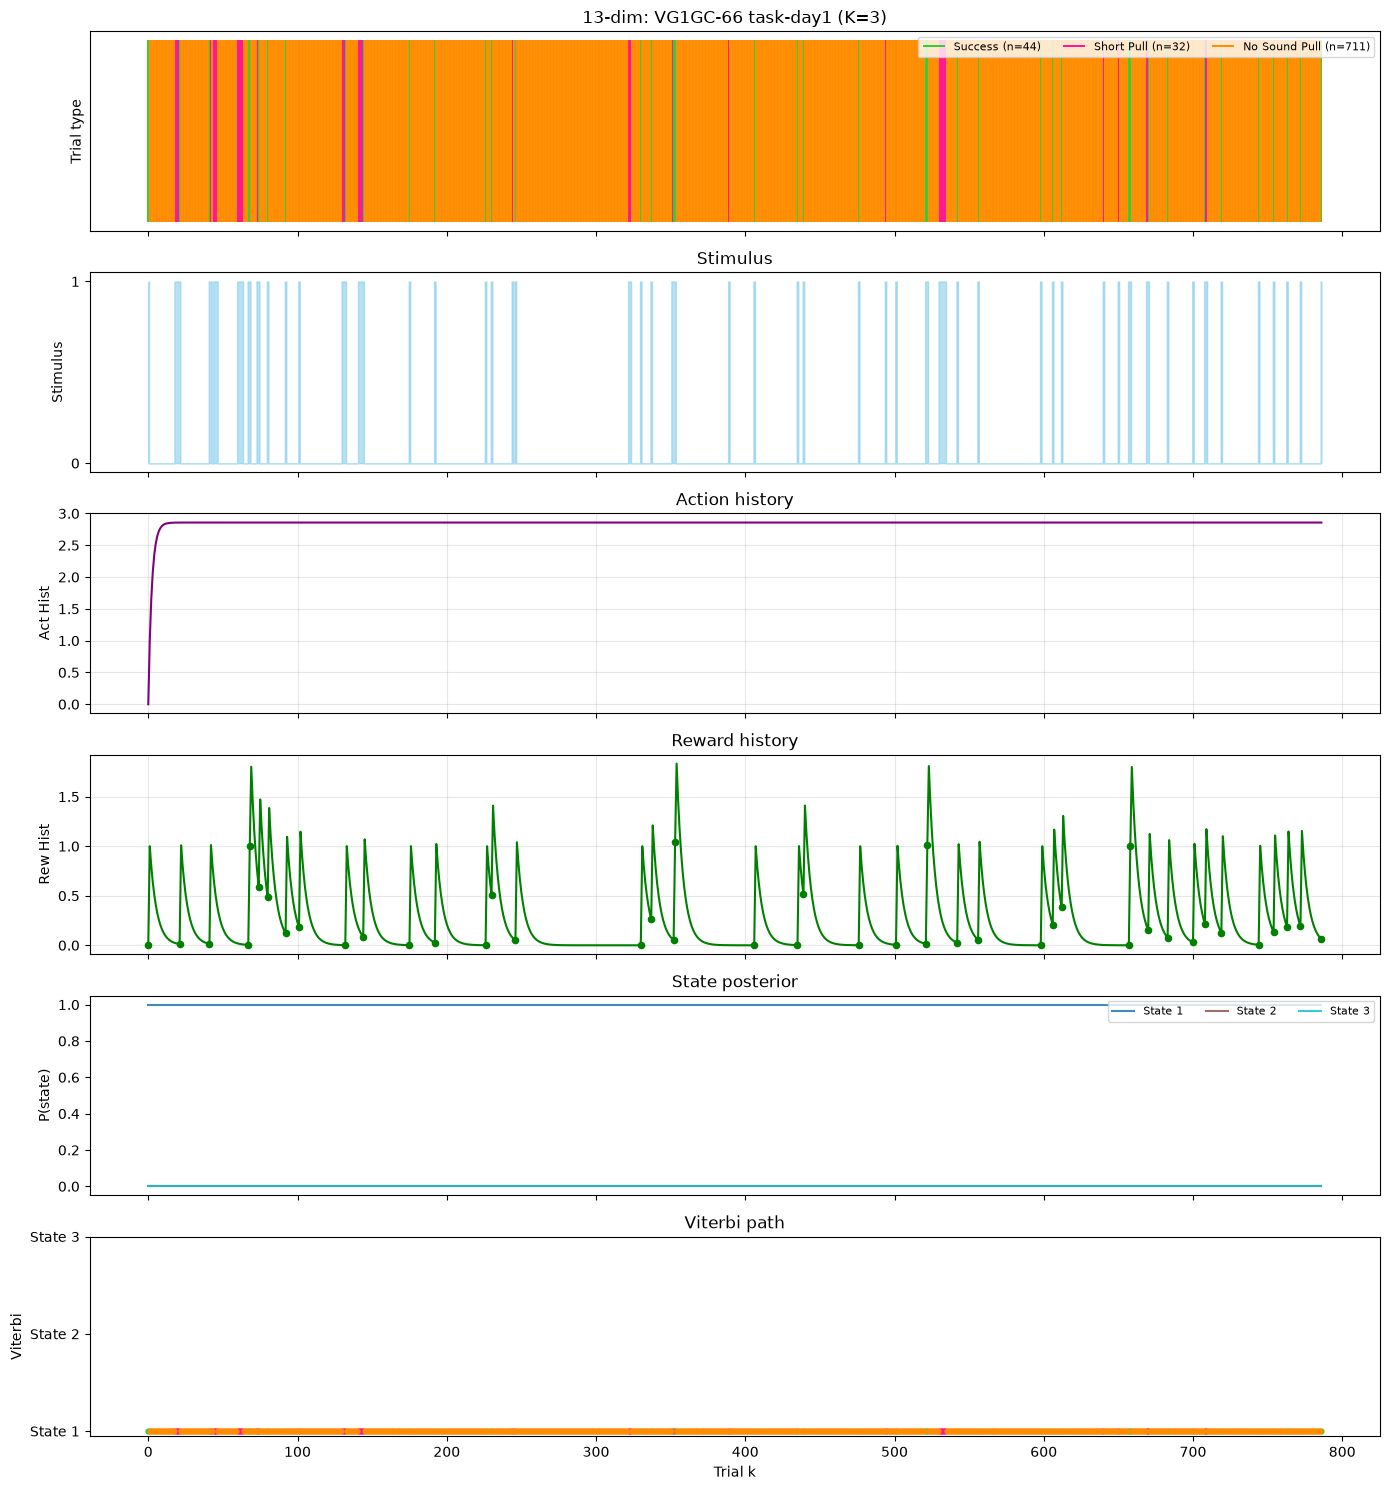

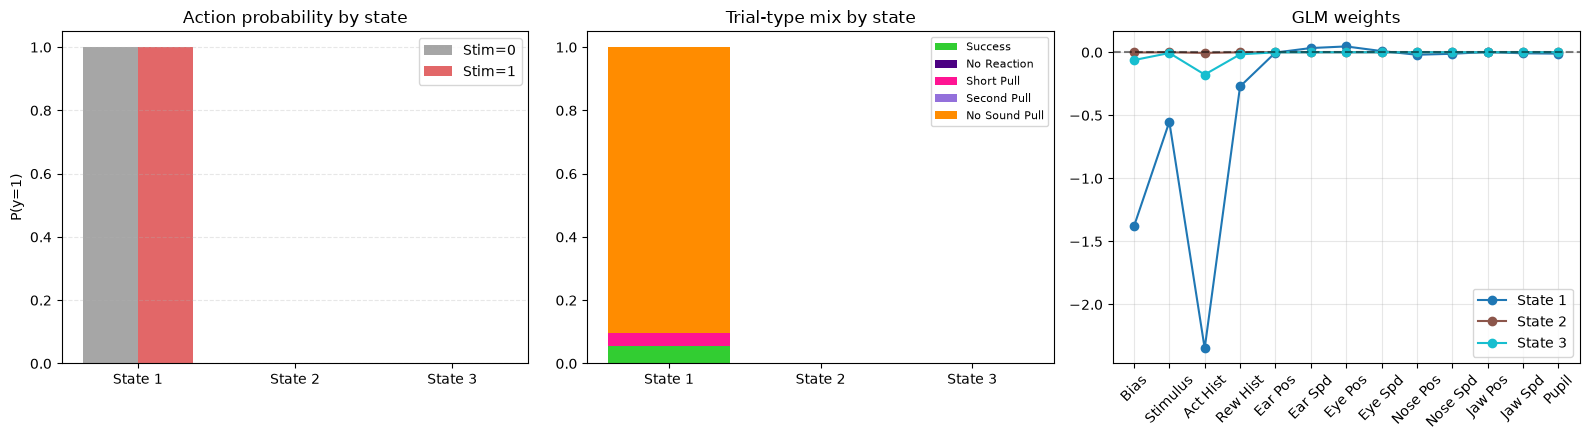

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 1.00
State 2 | Stim=0: 0.00  Stim=1: 0.00
State 3 | Stim=0: 0.00  Stim=1: 0.00
Viterbi occupancy: [787   0   0]

task-day3 (n=548 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-103.16


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-102.78


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-101.13
Best log_prob=-101.13


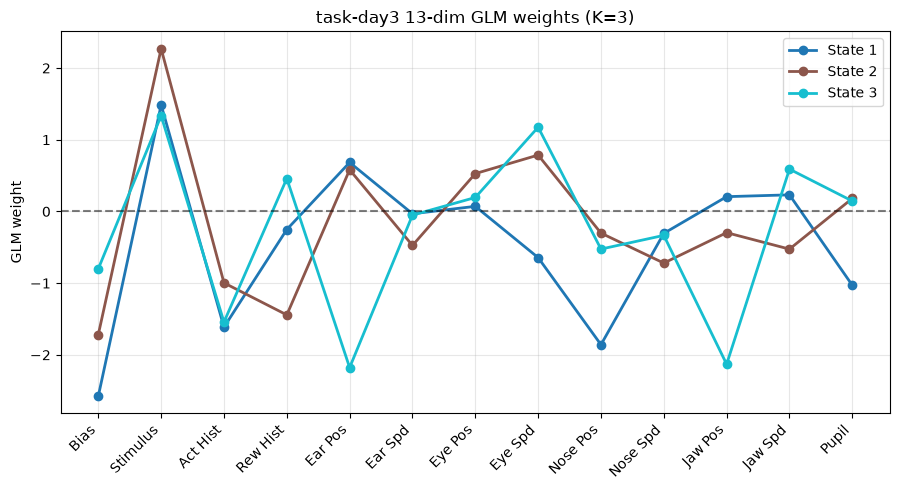

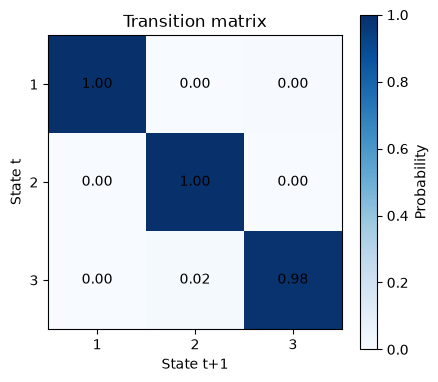

[[0.996 0.    0.004]
 [0.    1.    0.   ]
 [0.    0.015 0.985]]


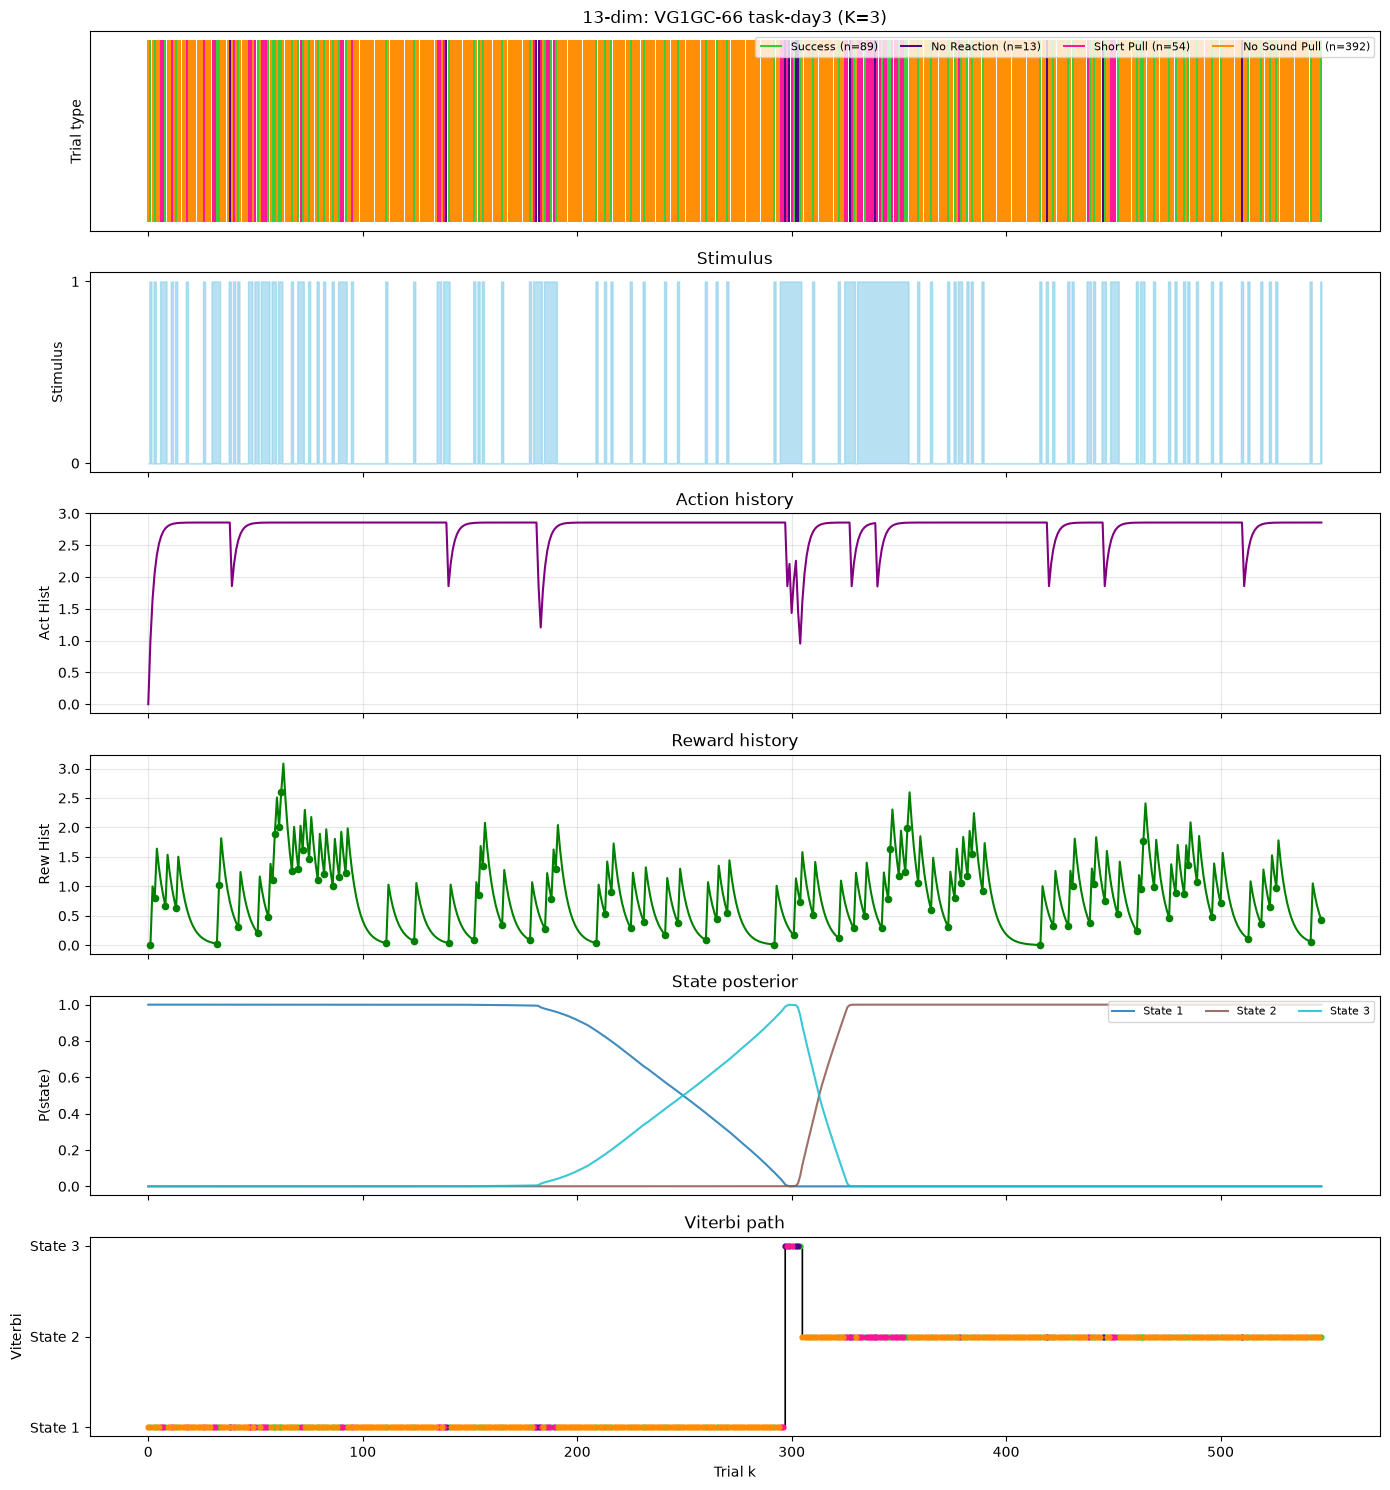

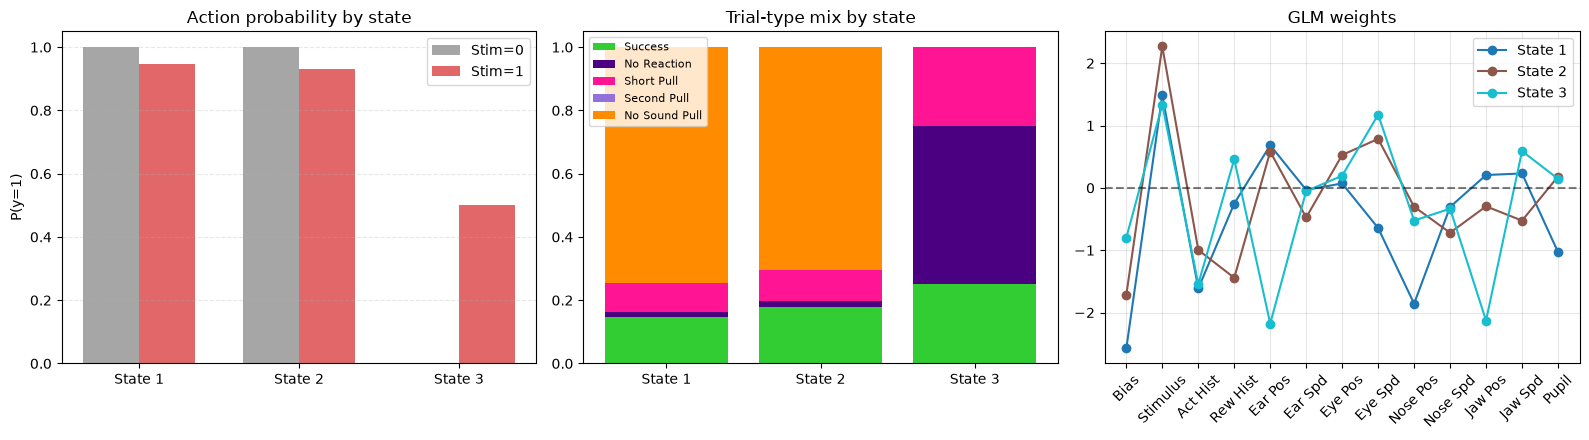

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.95
State 2 | Stim=0: 1.00  Stim=1: 0.93
State 3 | Stim=0: 0.00  Stim=1: 0.50
Viterbi occupancy: [297 243   8]

task-day4 (n=470 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-83.42


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-83.73


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-85.33
Best log_prob=-83.42


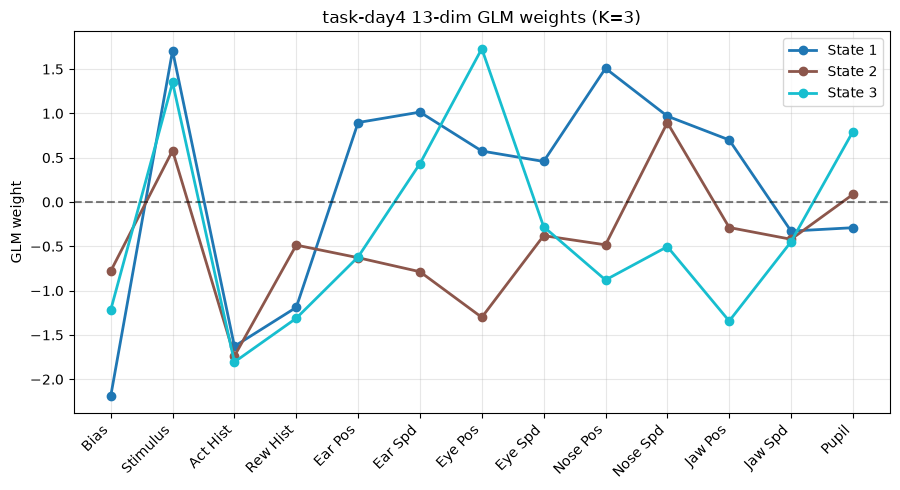

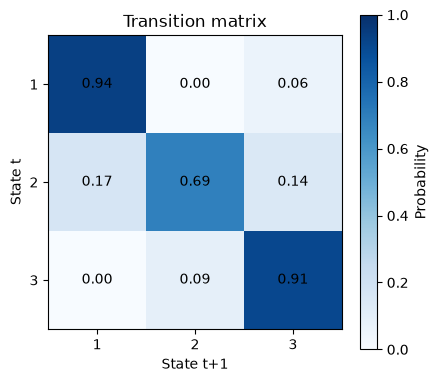

[[0.937 0.002 0.061]
 [0.166 0.691 0.143]
 [0.004 0.087 0.909]]


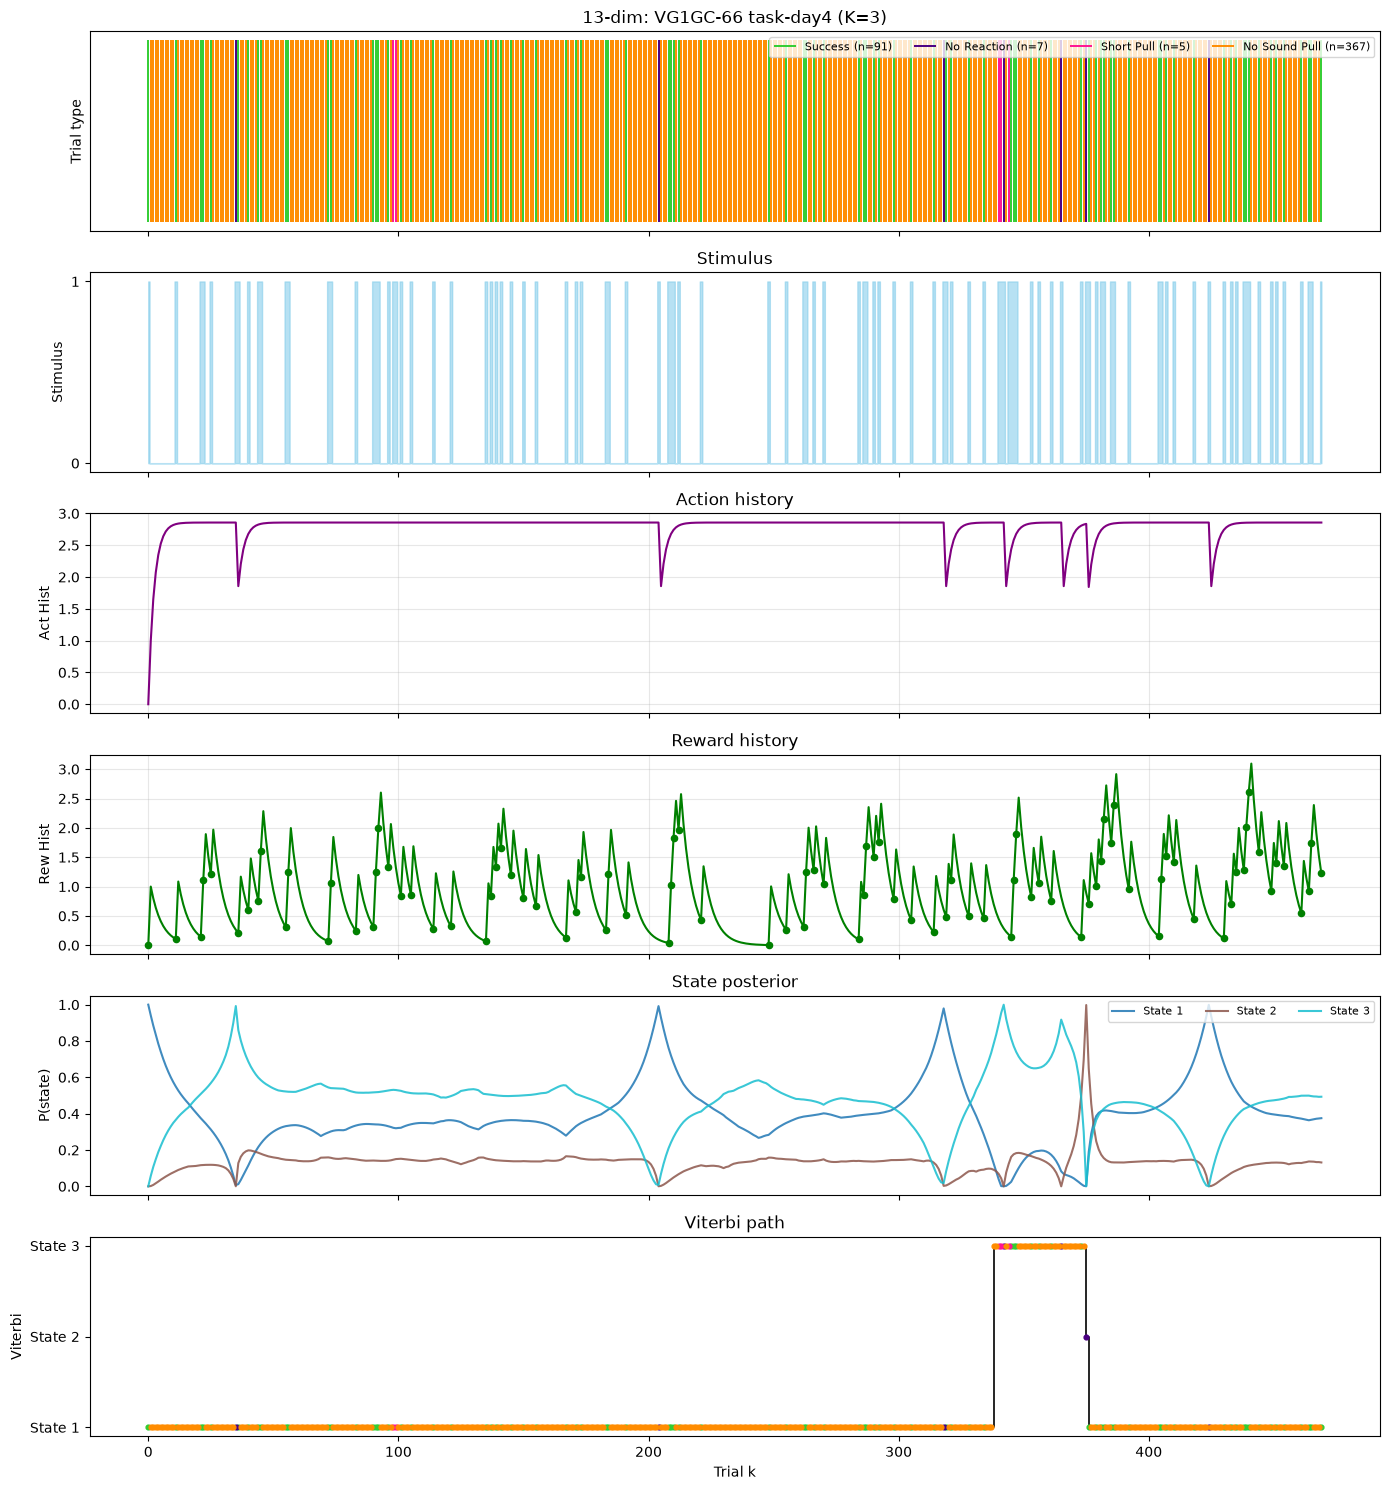

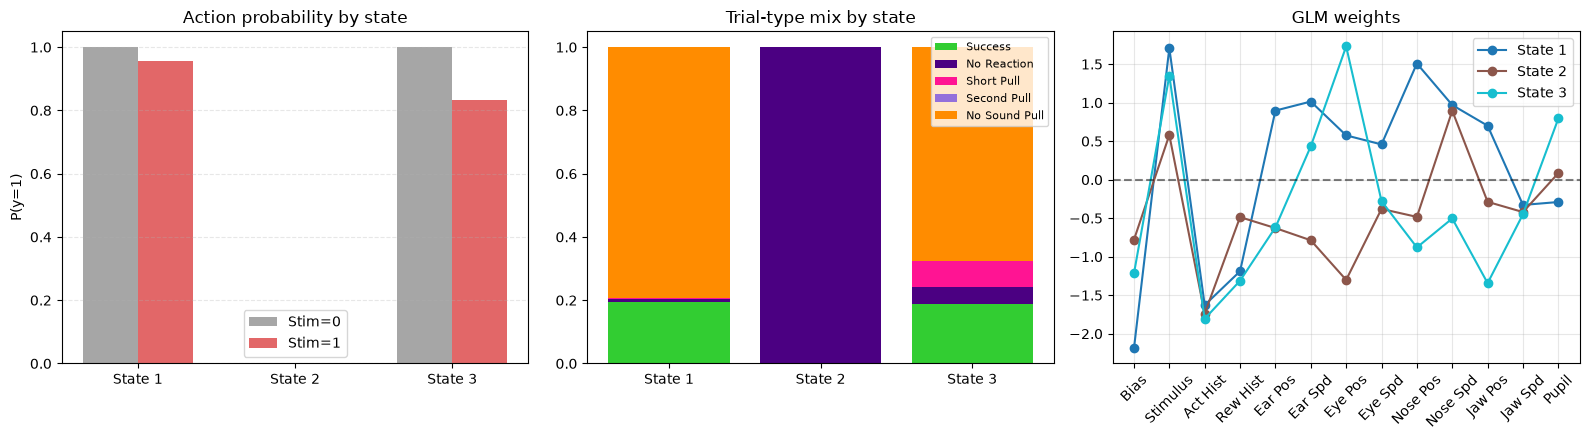

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.96
State 2 | Stim=0: 0.00  Stim=1: 0.00
State 3 | Stim=0: 1.00  Stim=1: 0.83
Viterbi occupancy: [432   1  37]

task-day5 (n=376 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-131.44


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-131.88


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-132.50
Best log_prob=-131.44


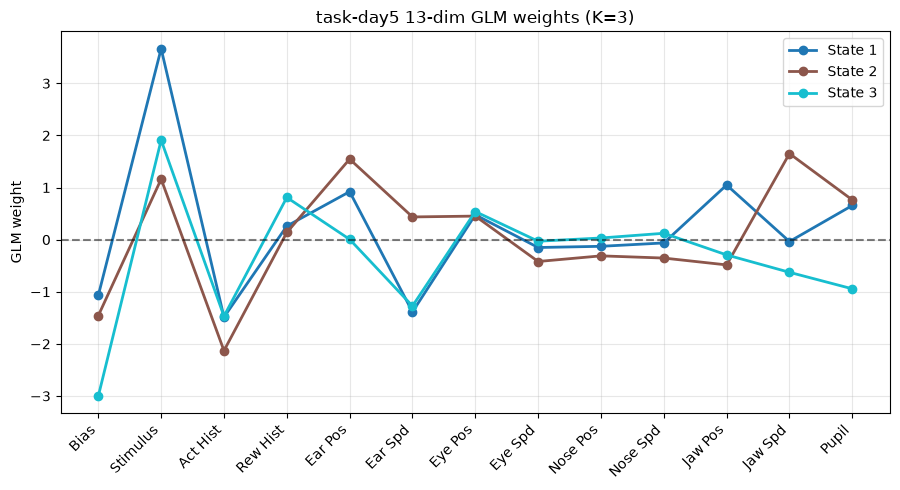

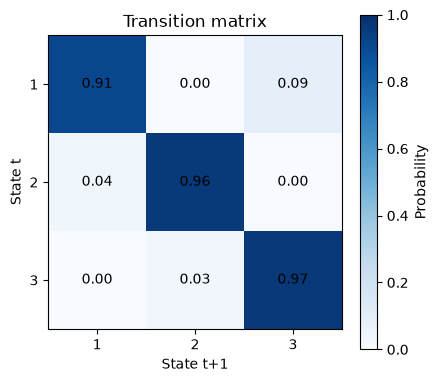

[[0.91  0.    0.09 ]
 [0.035 0.965 0.   ]
 [0.    0.032 0.968]]


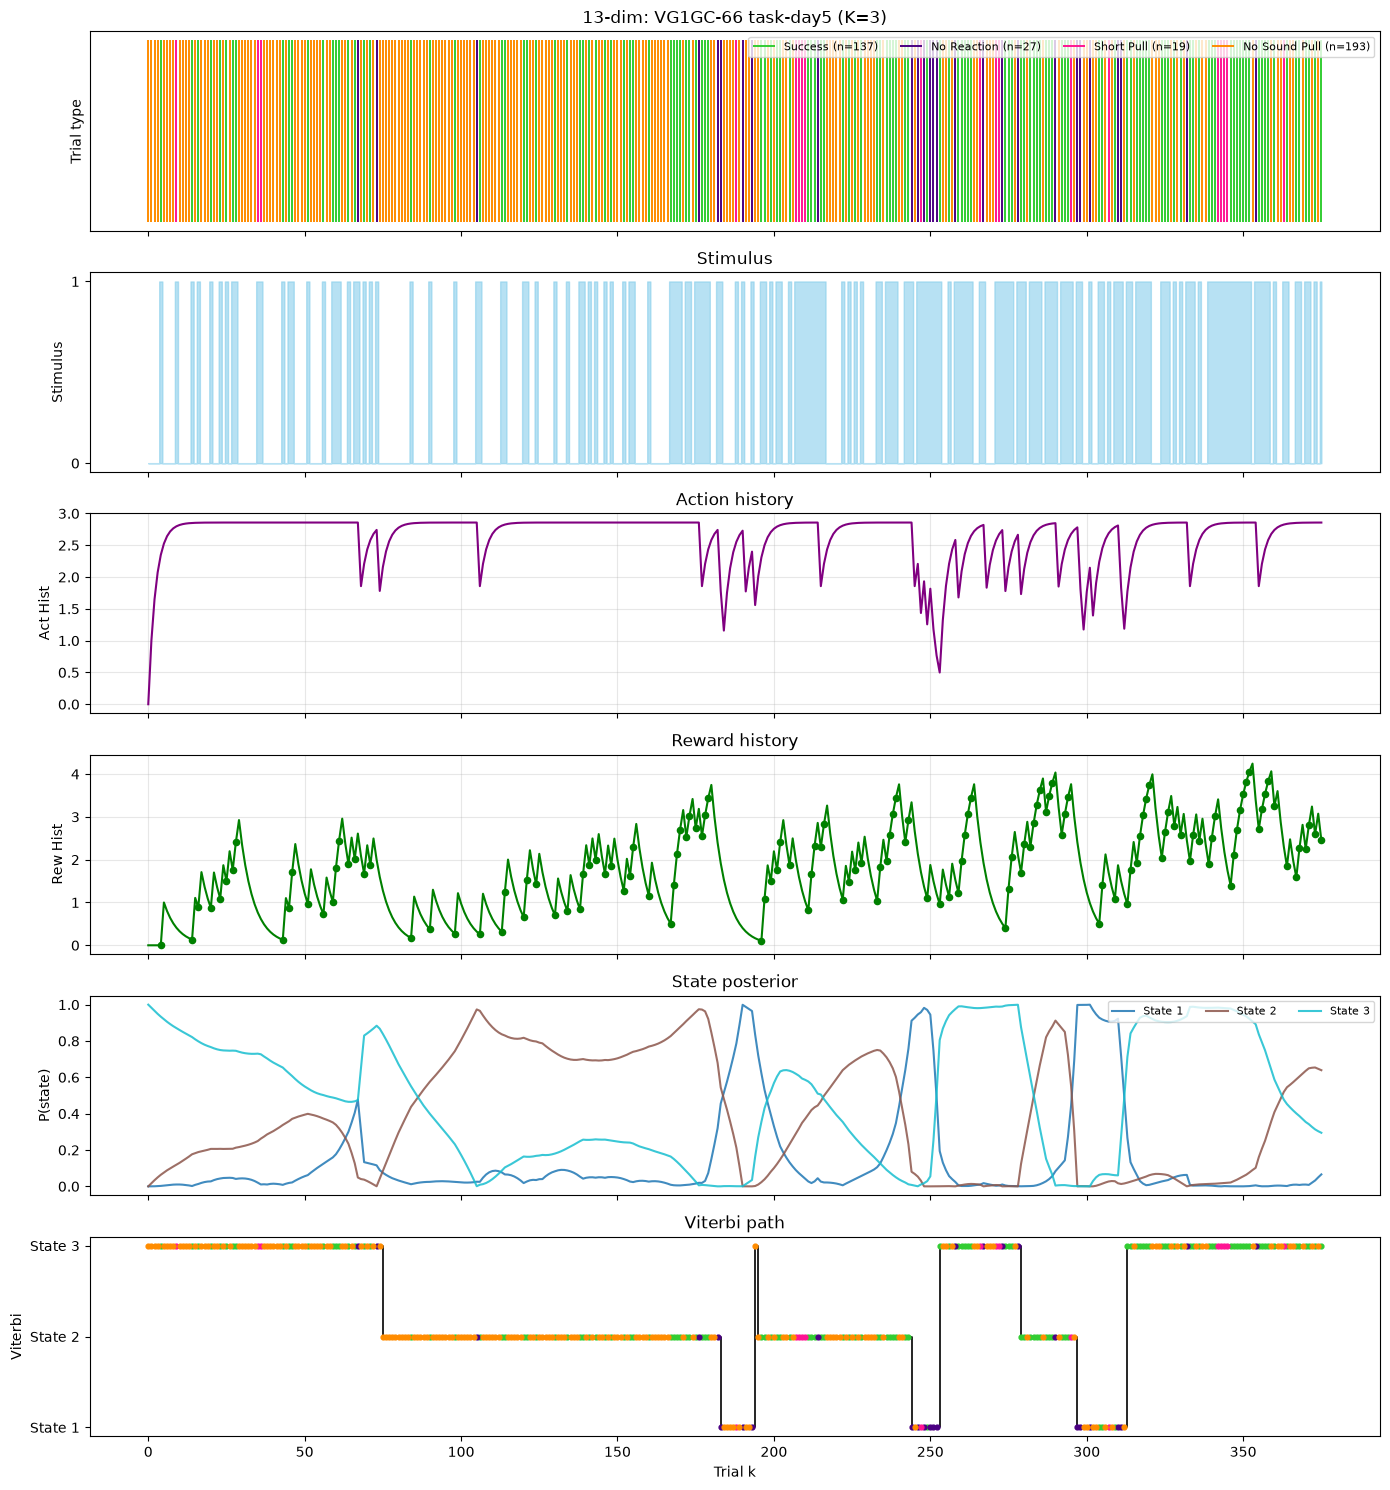

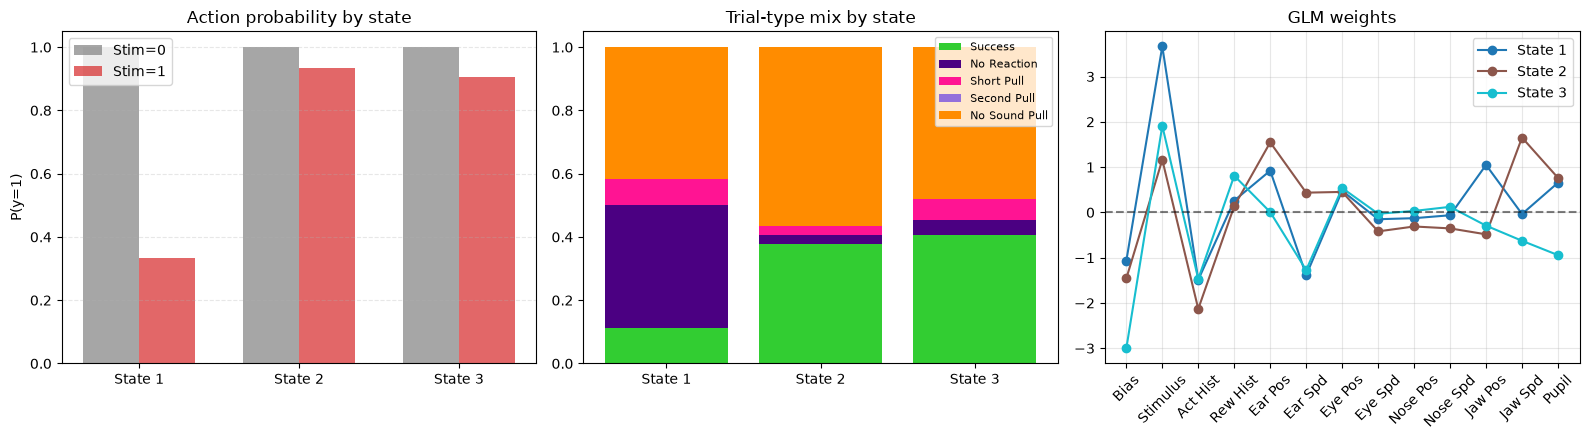

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.33
State 2 | Stim=0: 1.00  Stim=1: 0.93
State 3 | Stim=0: 1.00  Stim=1: 0.91
Viterbi occupancy: [ 36 175 165]

task-day6 (n=375 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-154.48


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-155.17


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-157.51
Best log_prob=-154.48


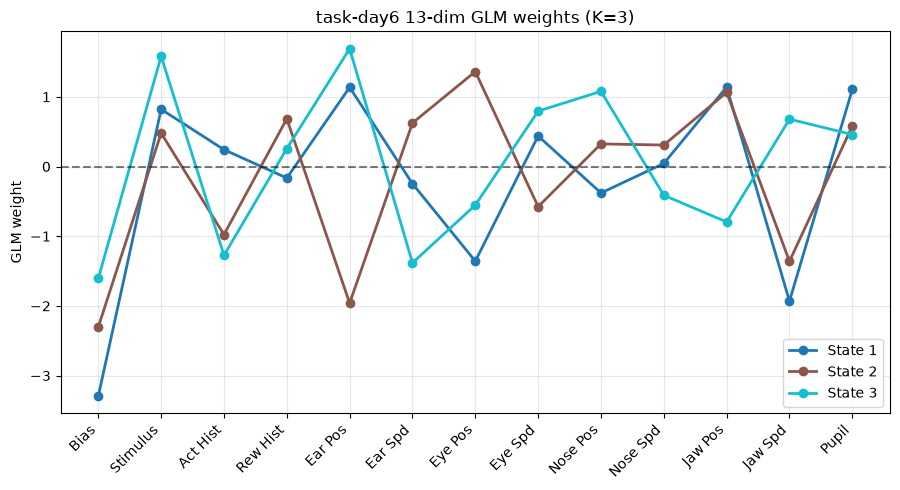

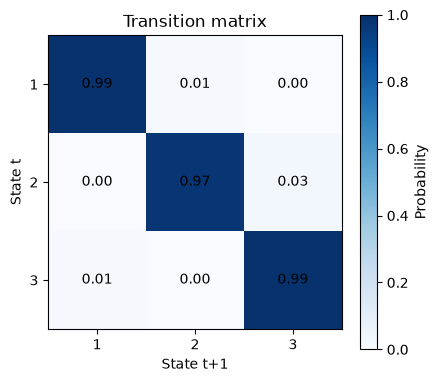

[[0.991 0.009 0.   ]
 [0.    0.974 0.026]
 [0.009 0.    0.991]]


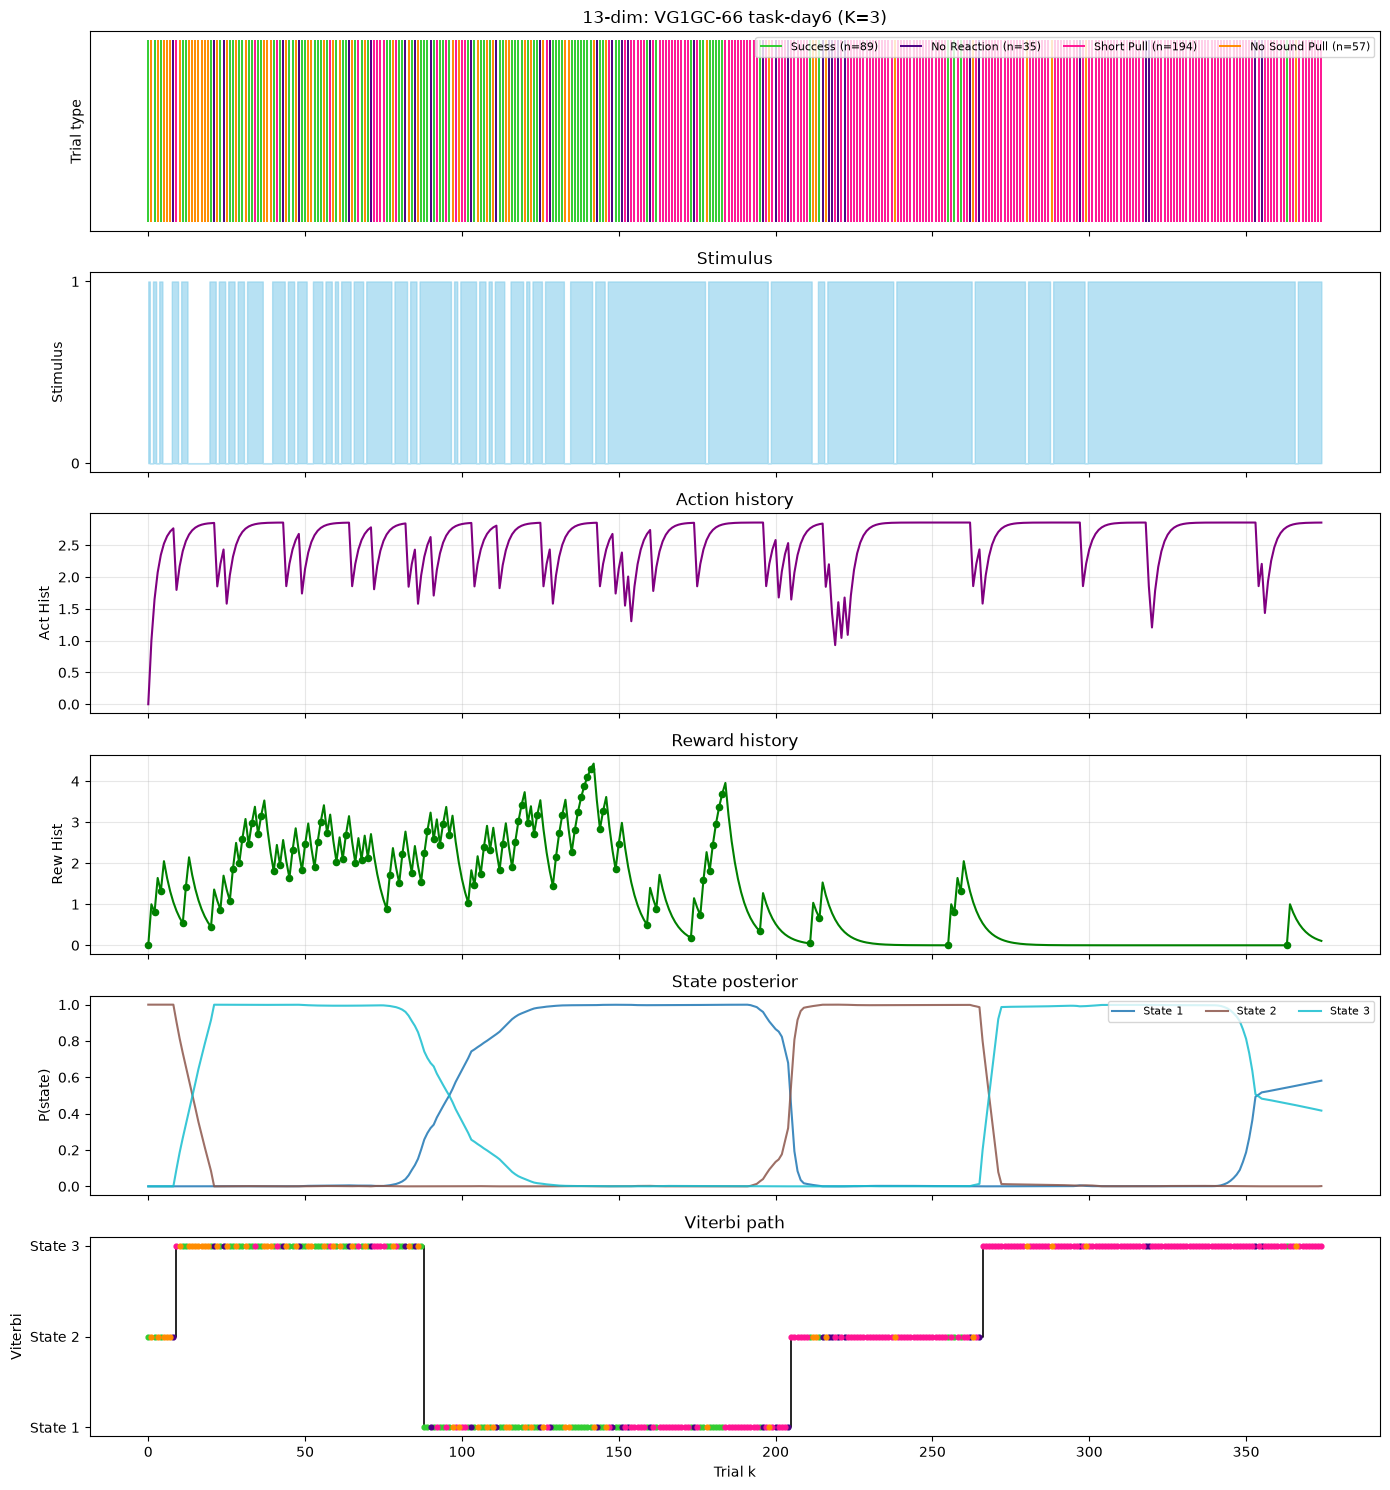

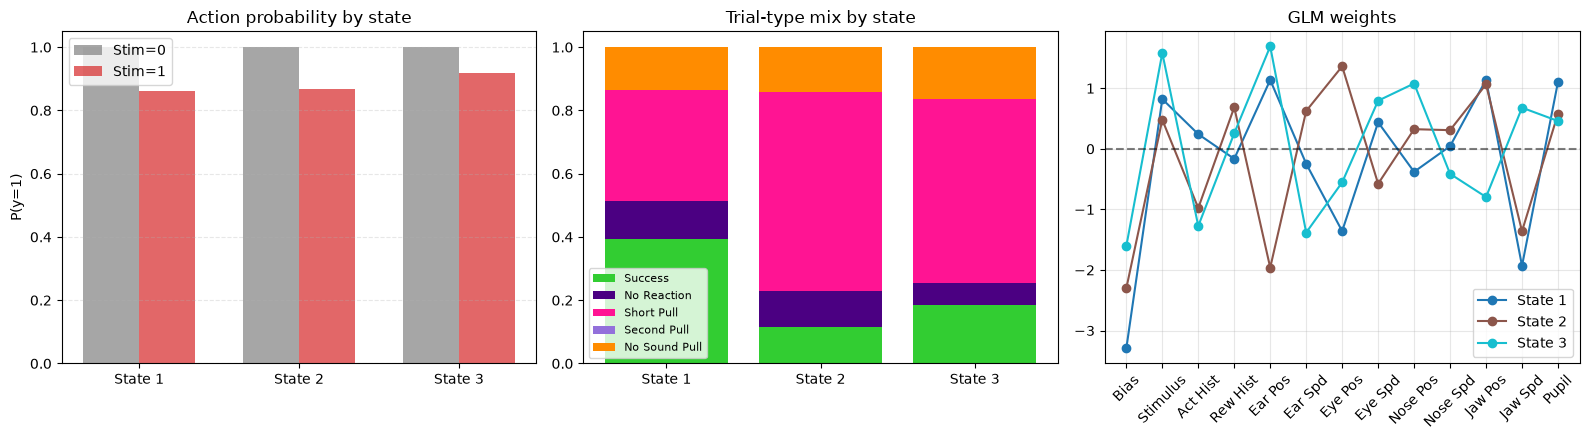

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.86
State 2 | Stim=0: 1.00  Stim=1: 0.87
State 3 | Stim=0: 1.00  Stim=1: 0.92
Viterbi occupancy: [117  70 188]

task-day7 (n=386 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-140.86


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-142.55


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-138.21
Best log_prob=-138.21


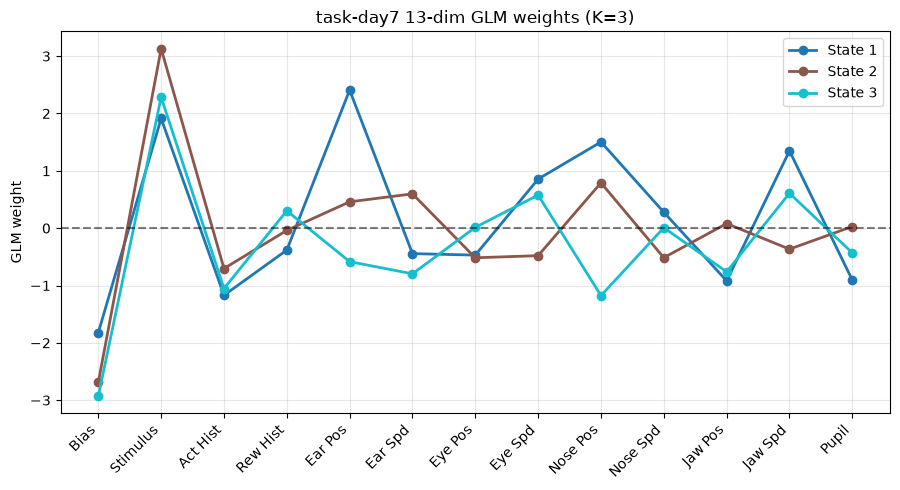

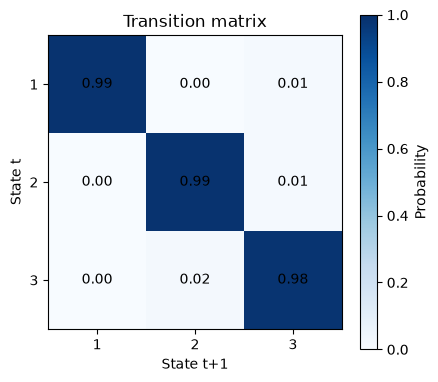

[[0.986 0.    0.014]
 [0.    0.988 0.012]
 [0.    0.017 0.983]]


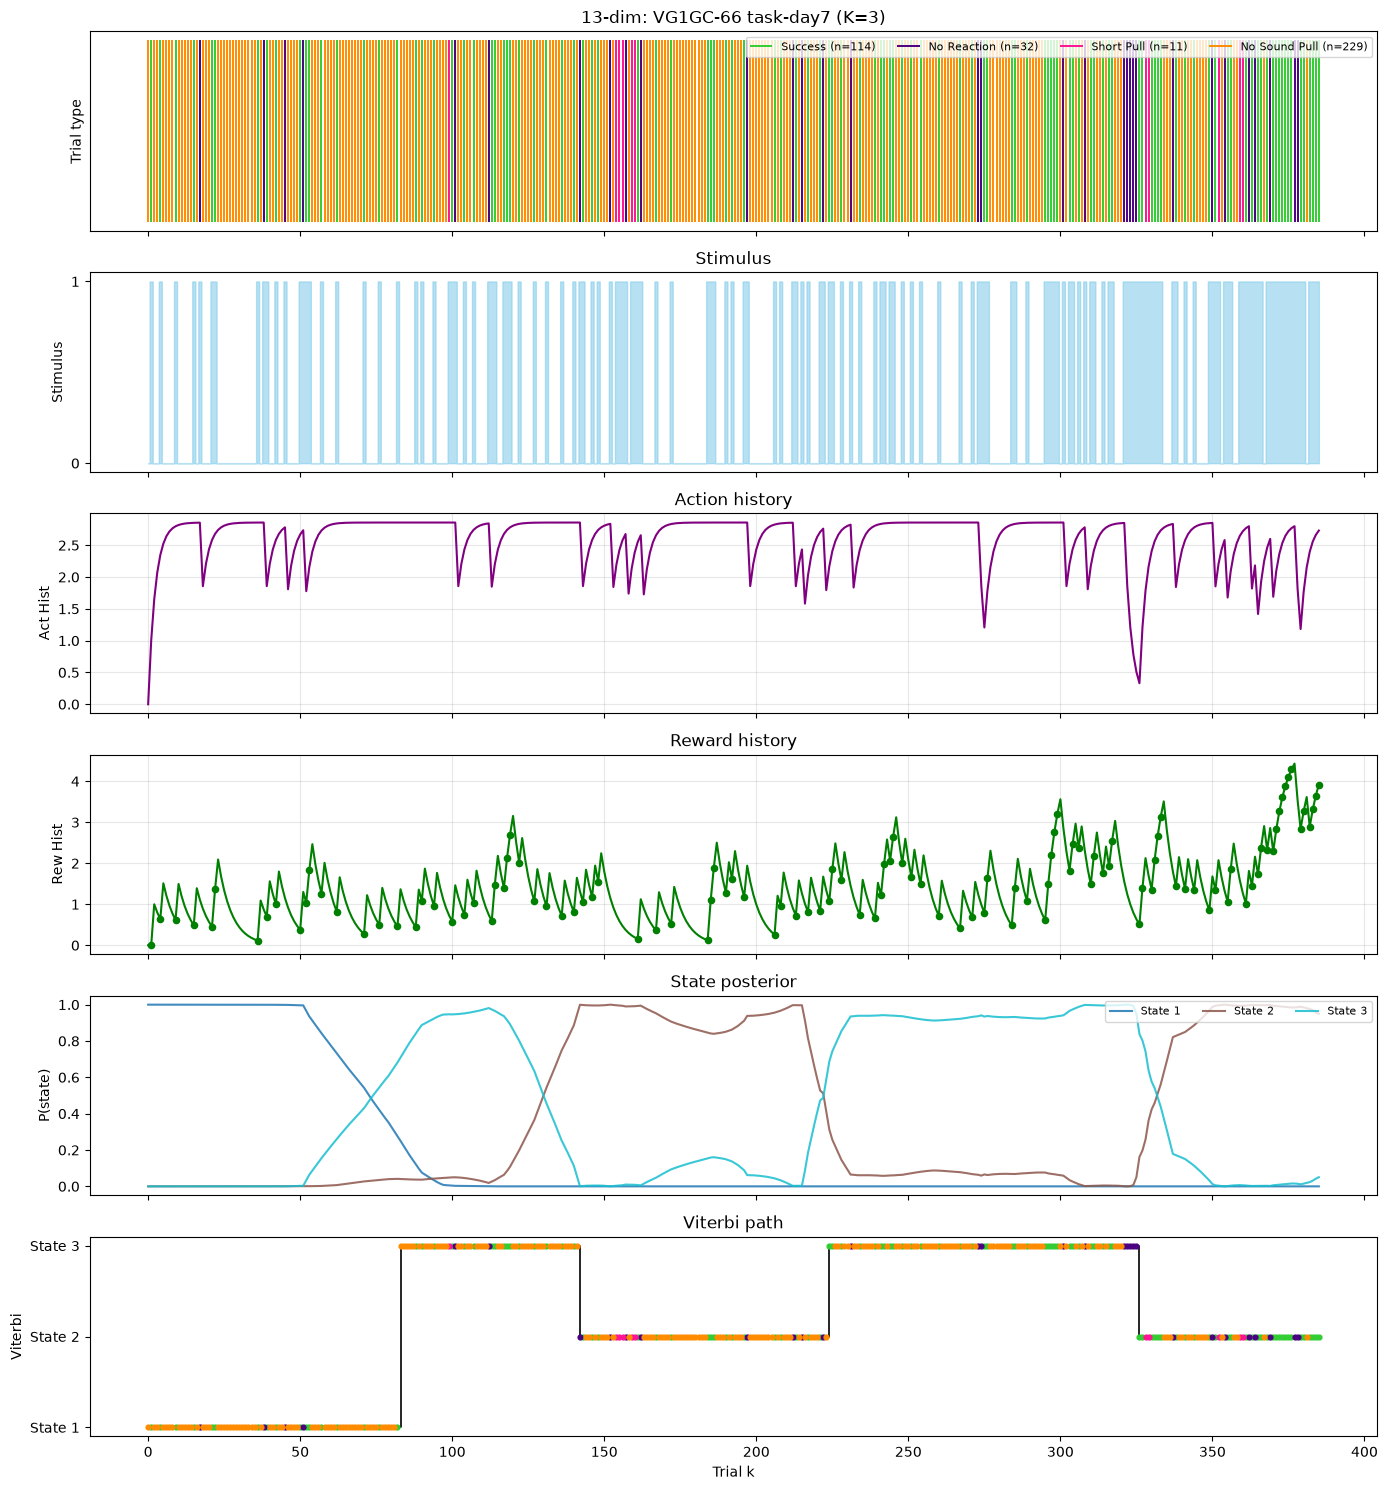

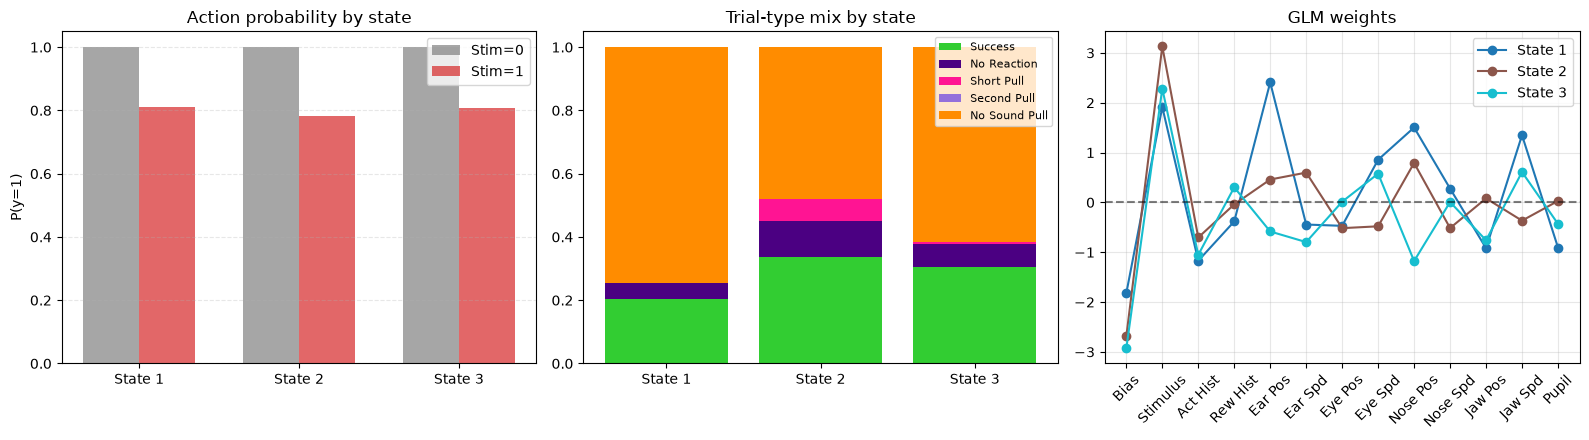

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.81
State 2 | Stim=0: 1.00  Stim=1: 0.78
State 3 | Stim=0: 1.00  Stim=1: 0.81
Viterbi occupancy: [ 83 142 161]

task-day8 (n=437 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-155.40


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-157.06


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-155.34
Best log_prob=-155.34


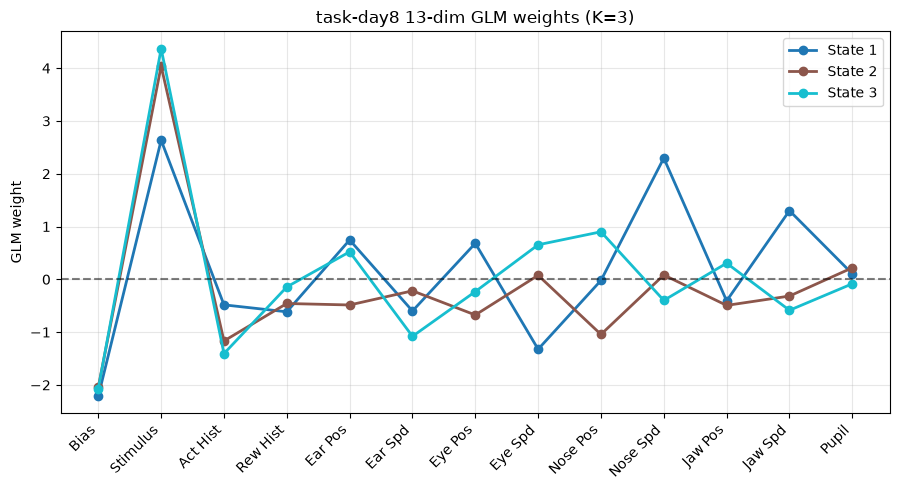

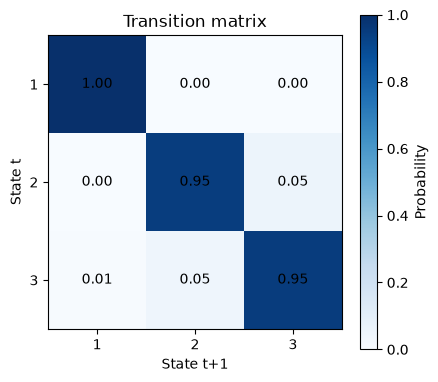

[[1.    0.    0.   ]
 [0.    0.949 0.051]
 [0.005 0.045 0.949]]


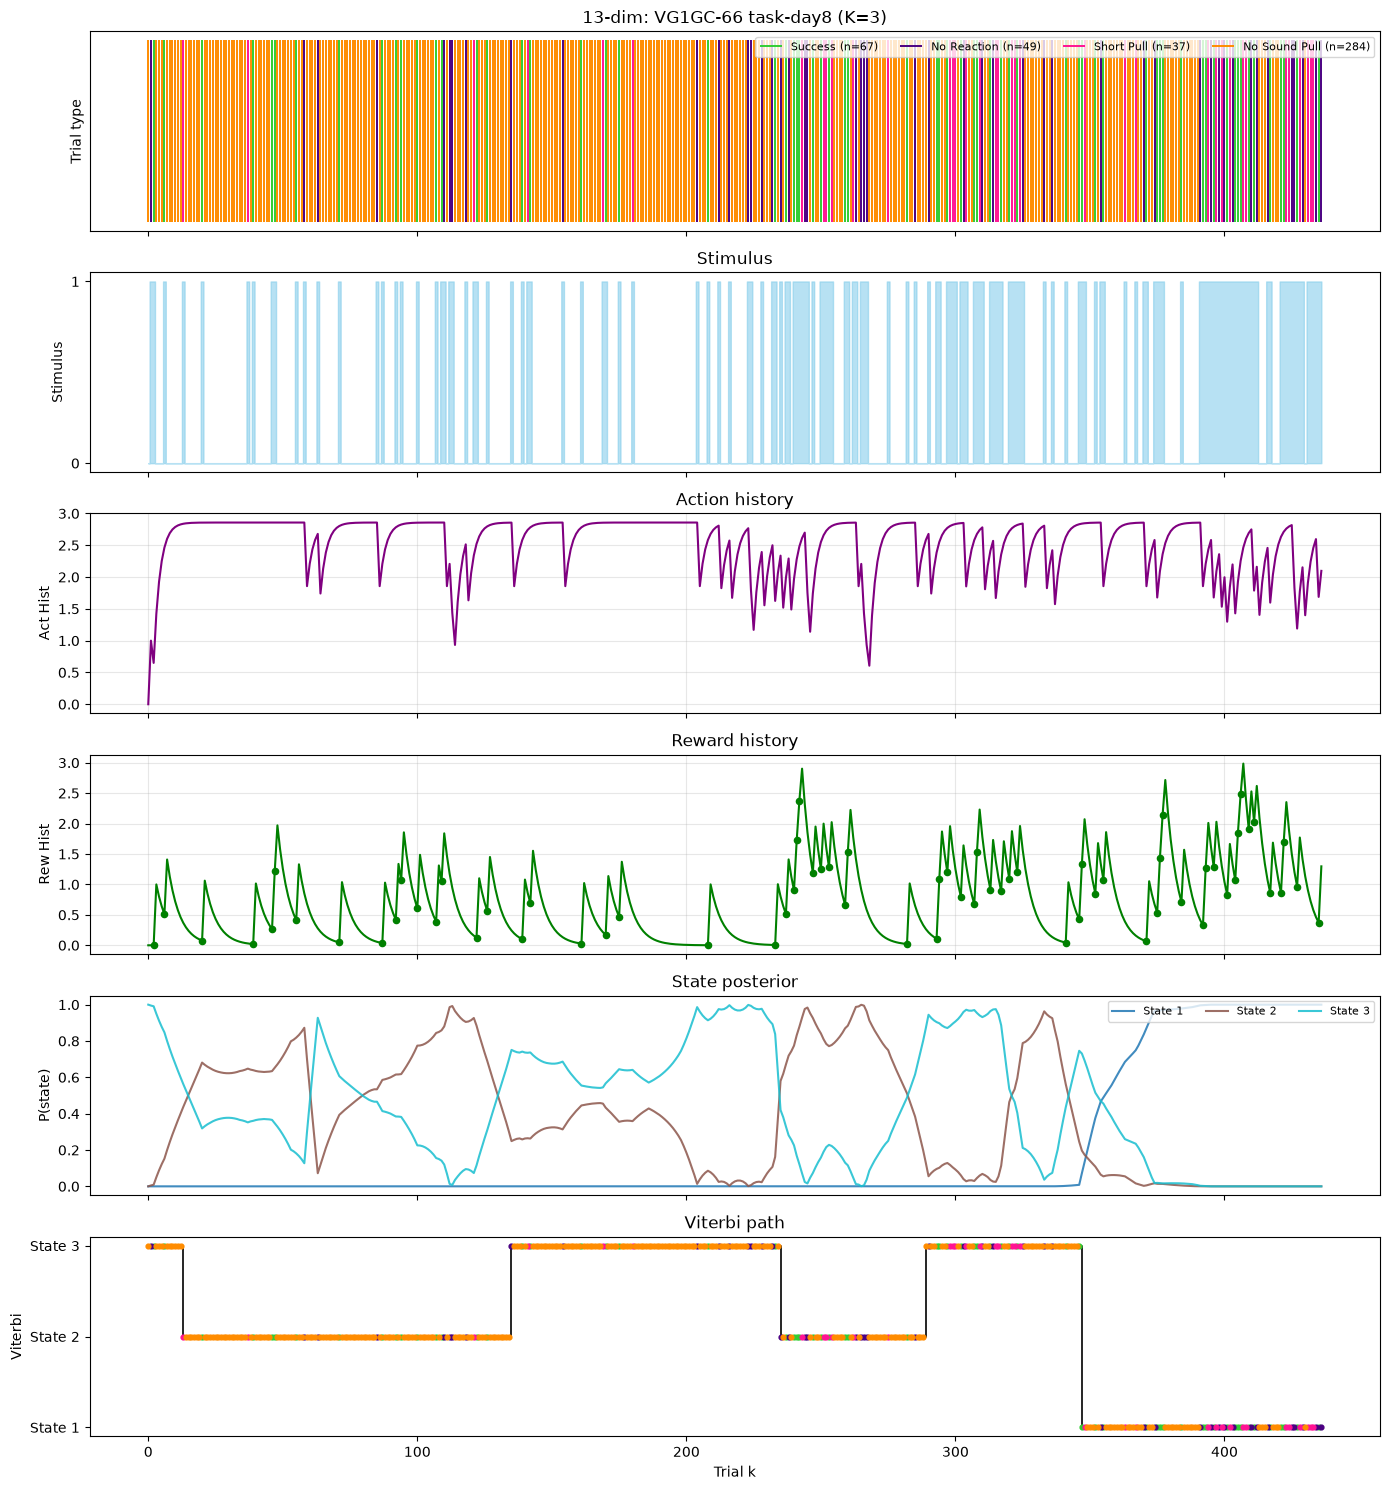

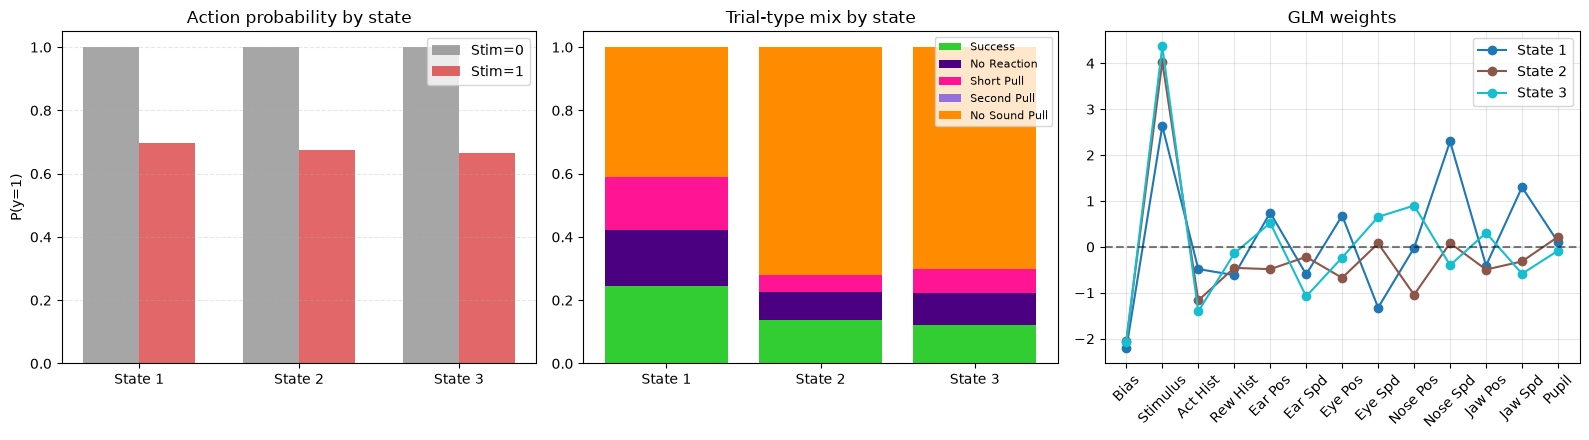

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.70
State 2 | Stim=0: 1.00  Stim=1: 0.67
State 3 | Stim=0: 1.00  Stim=1: 0.67
Viterbi occupancy: [ 90 176 171]

task-day9 (n=770 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-109.30


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-109.48


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-110.06
Best log_prob=-109.30


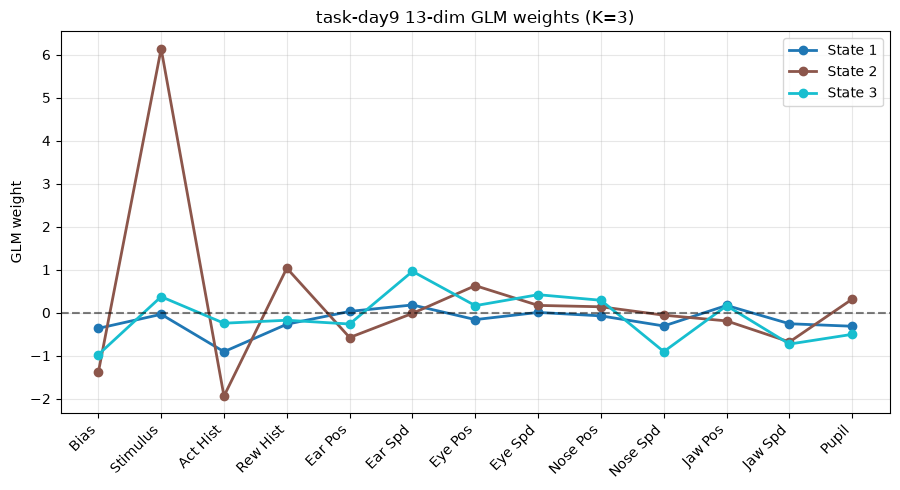

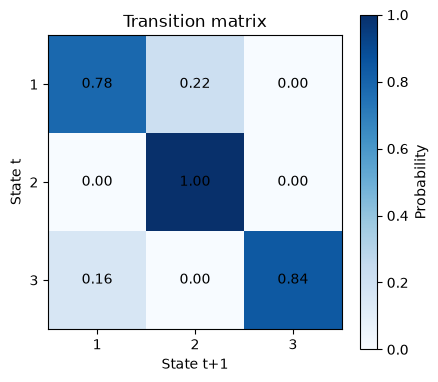

[[0.782 0.218 0.   ]
 [0.    1.    0.   ]
 [0.157 0.    0.843]]


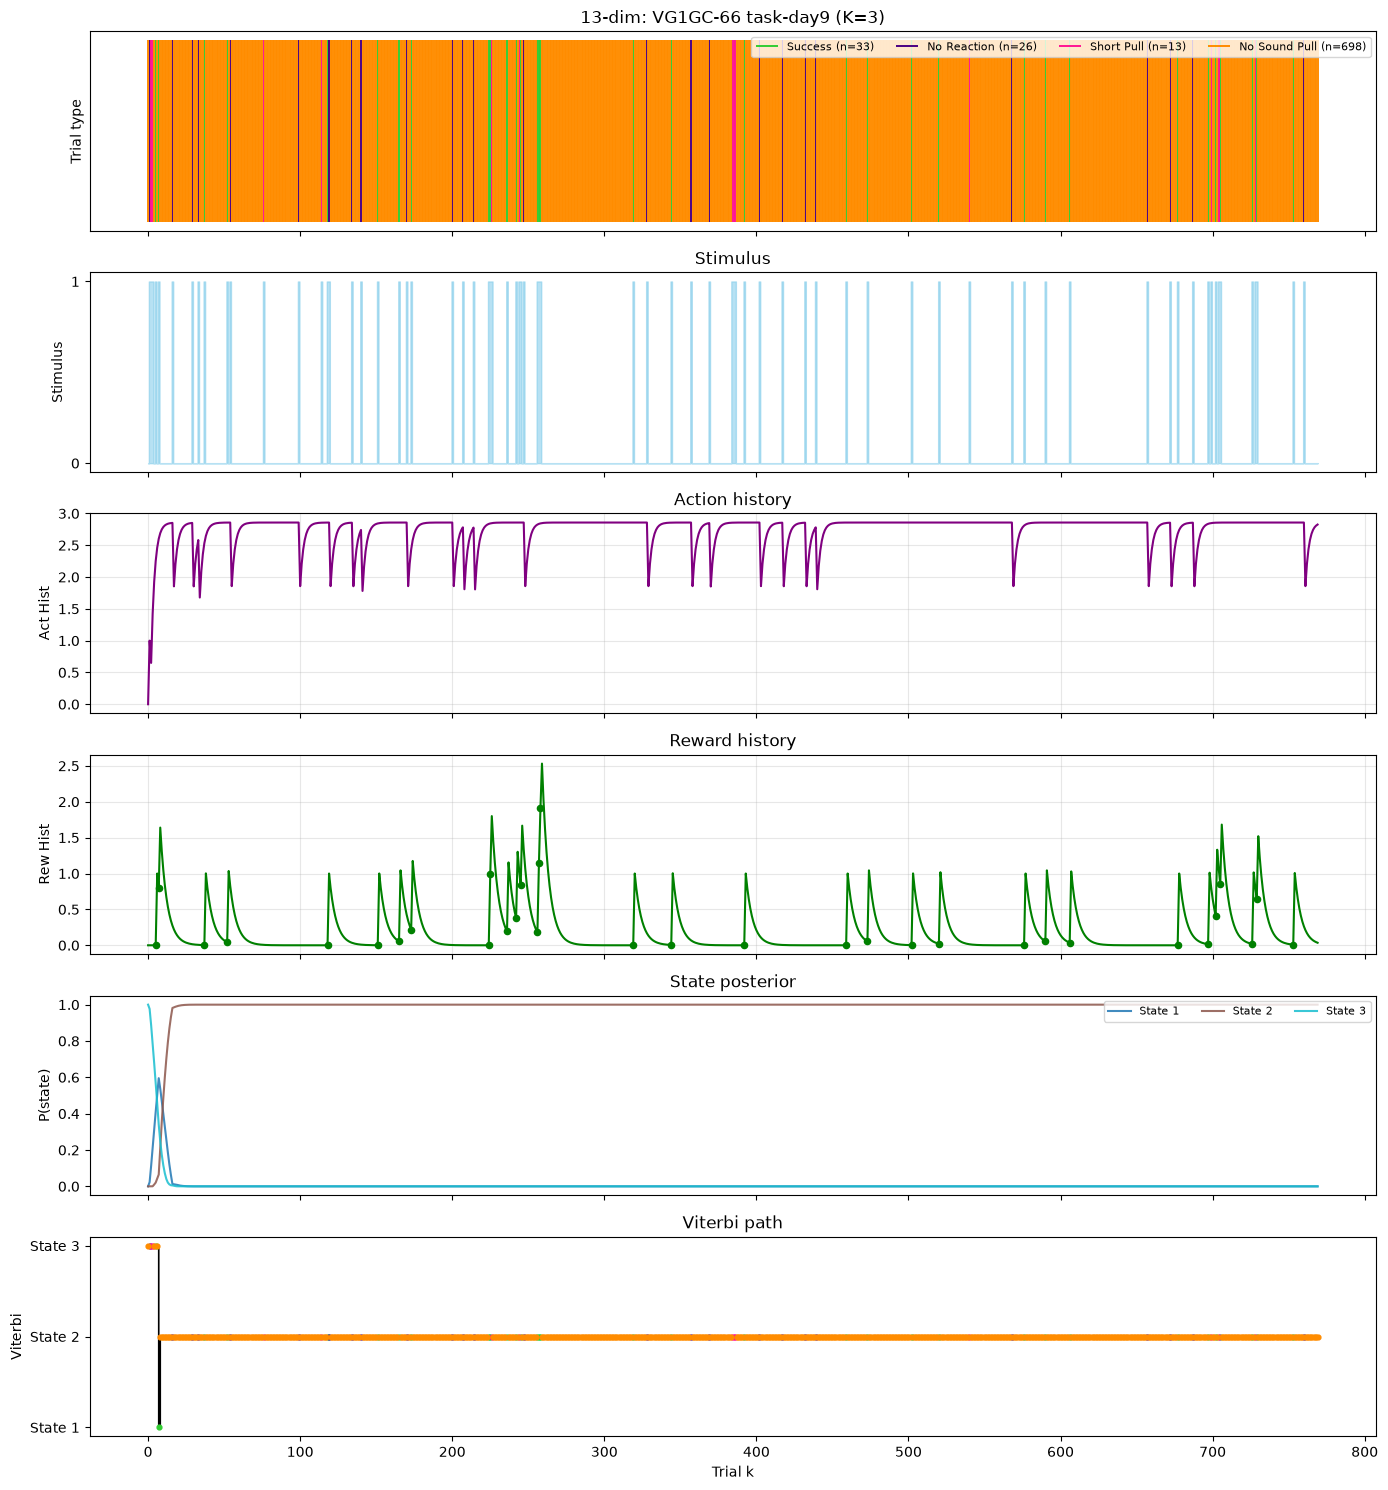

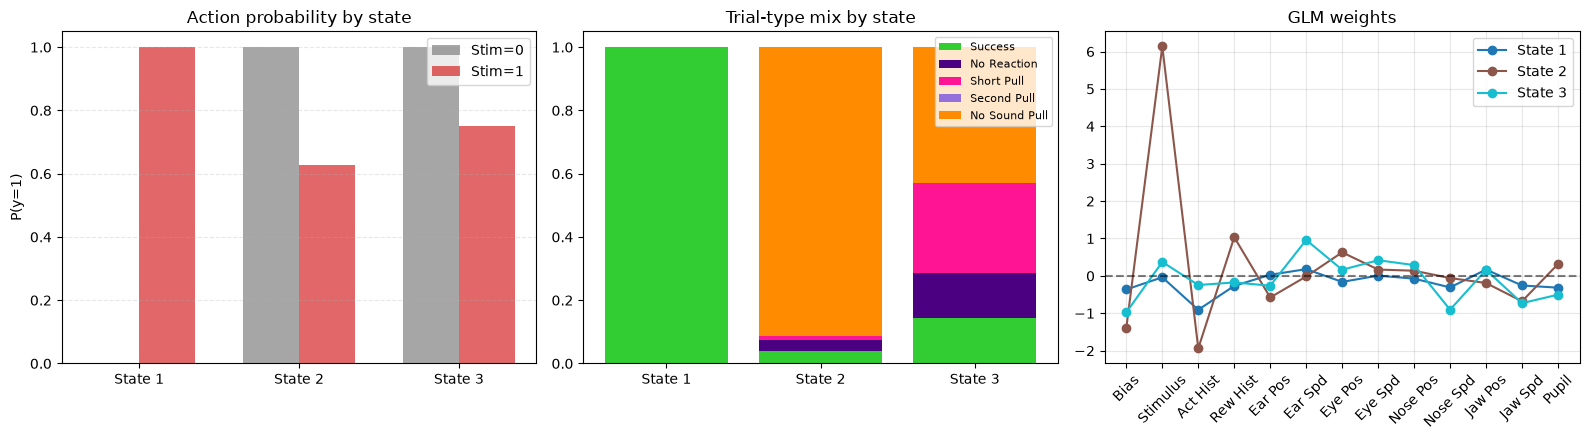

--- P(action | stim, state) ---
State 1 | Stim=0: 0.00  Stim=1: 1.00
State 2 | Stim=0: 1.00  Stim=1: 0.63
State 3 | Stim=0: 1.00  Stim=1: 0.75
Viterbi occupancy: [  1 762   7]

task-day10 (n=397 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-148.57


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-157.32


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-153.51
Best log_prob=-148.57


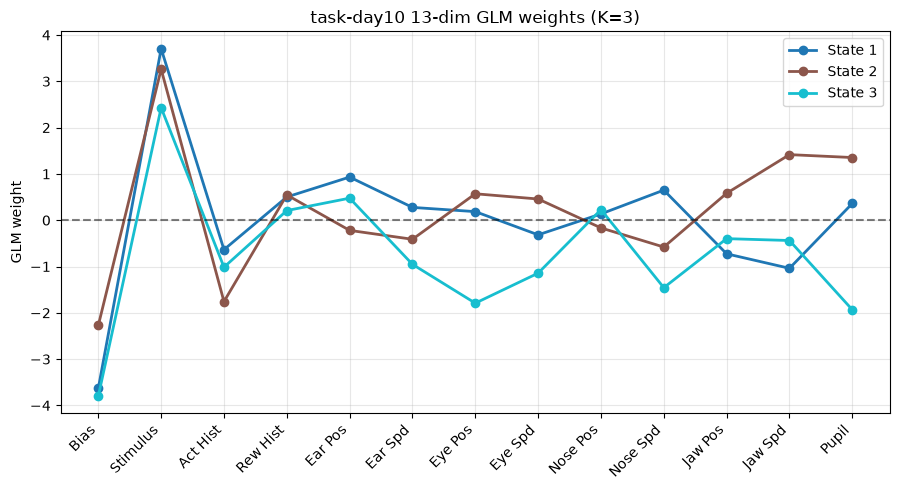

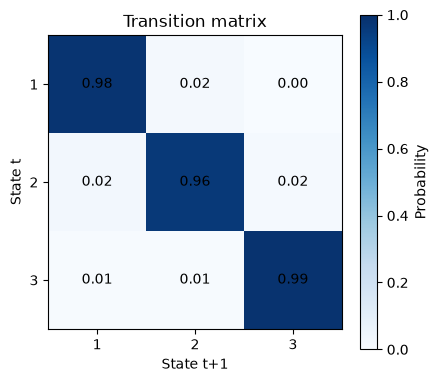

[[0.983 0.017 0.   ]
 [0.024 0.961 0.015]
 [0.007 0.007 0.985]]


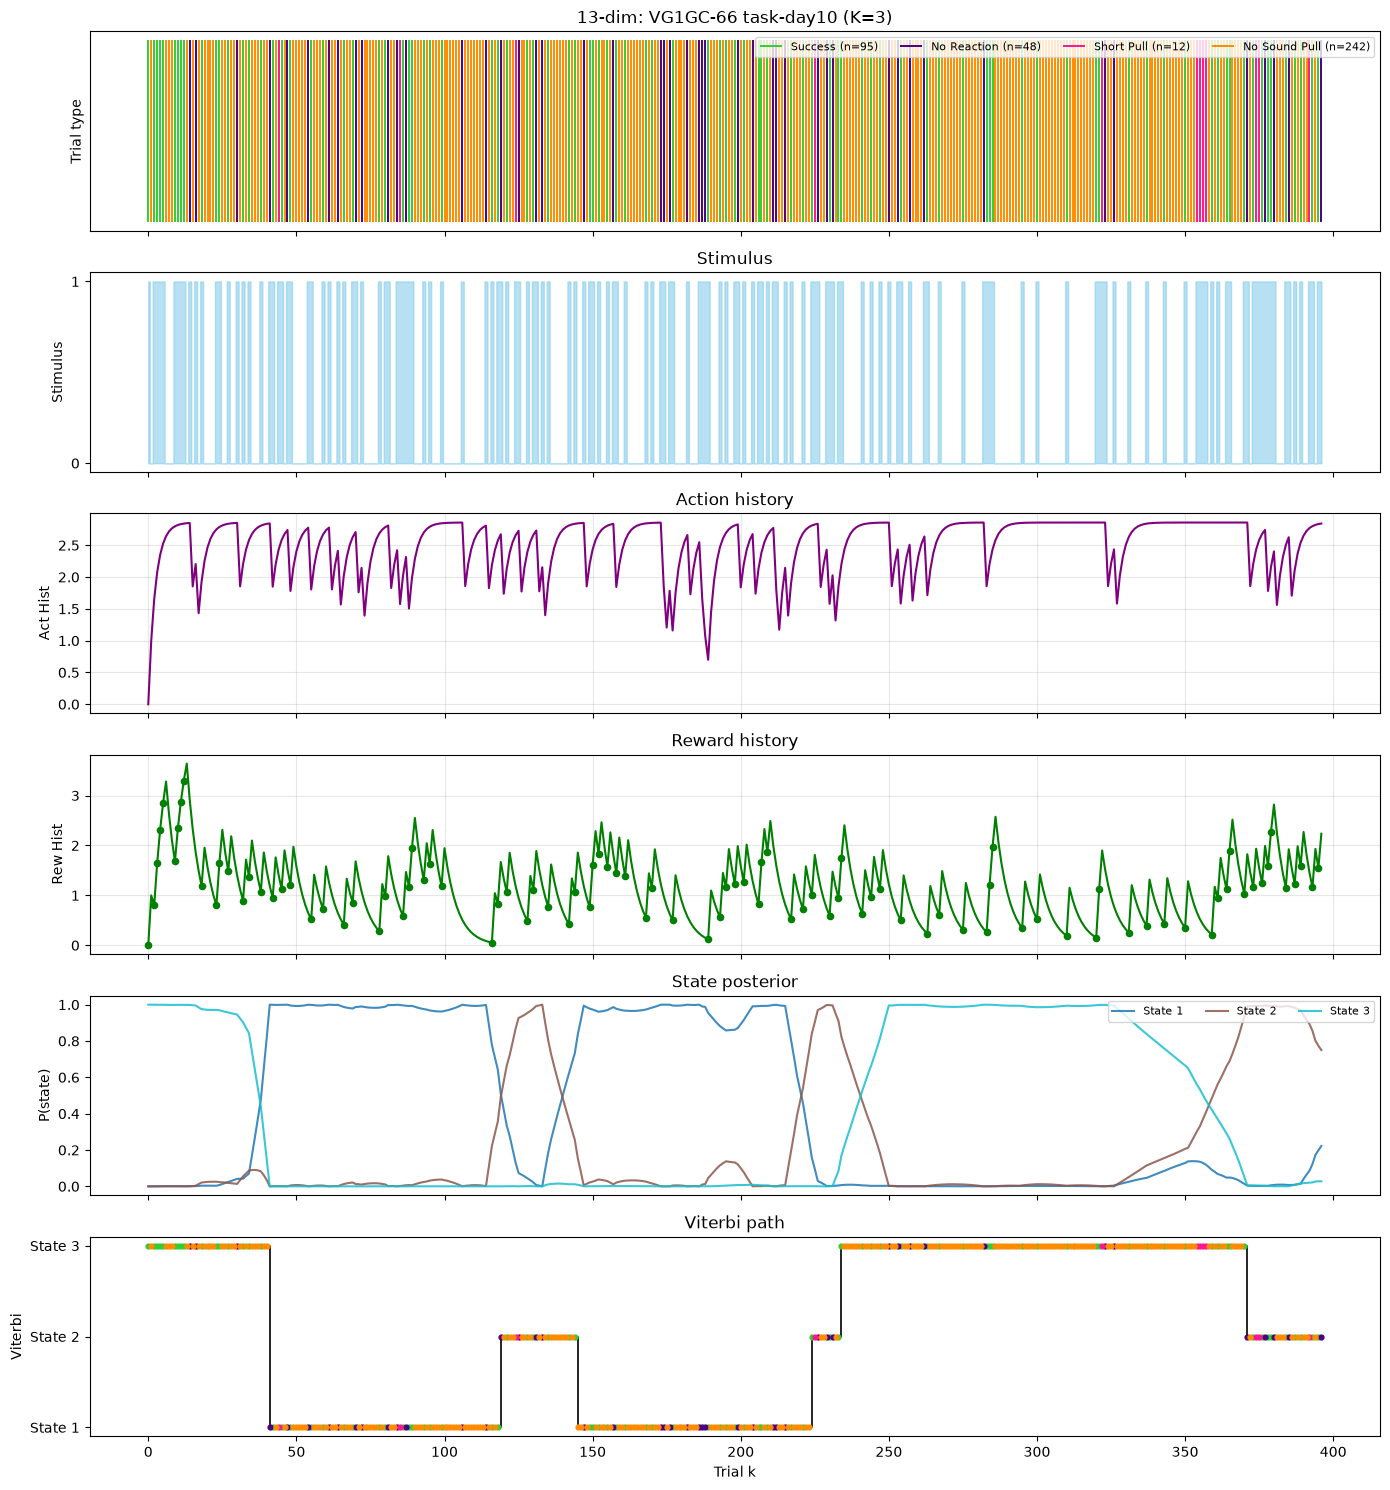

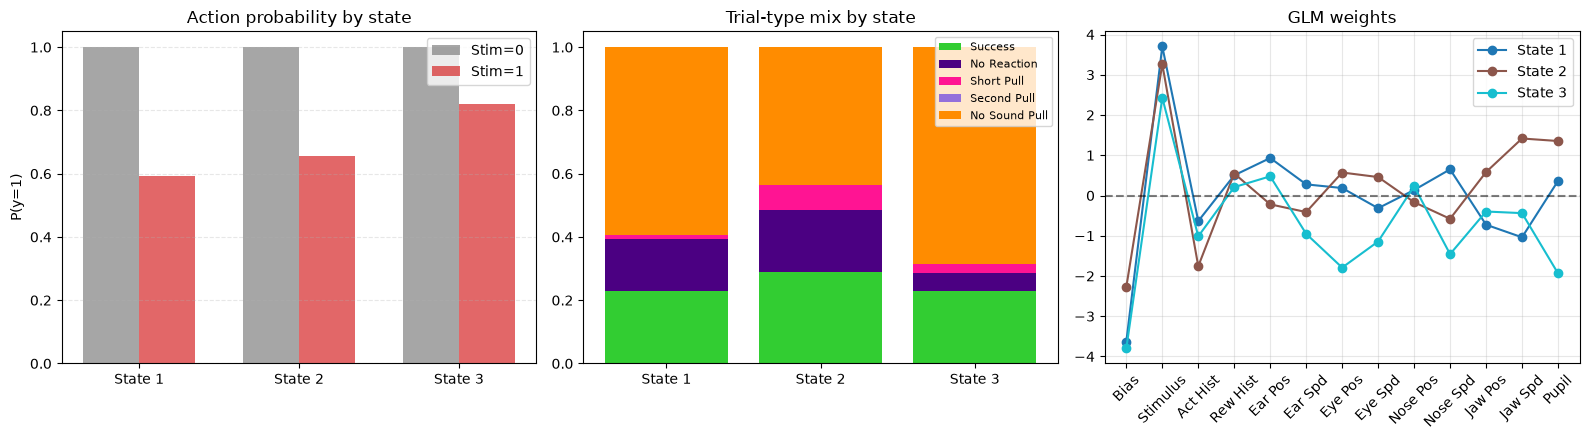

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.59
State 2 | Stim=0: 1.00  Stim=1: 0.66
State 3 | Stim=0: 1.00  Stim=1: 0.82
Viterbi occupancy: [157  62 178]

task-day11 (n=406 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-210.55


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-214.38


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-215.39
Best log_prob=-210.55


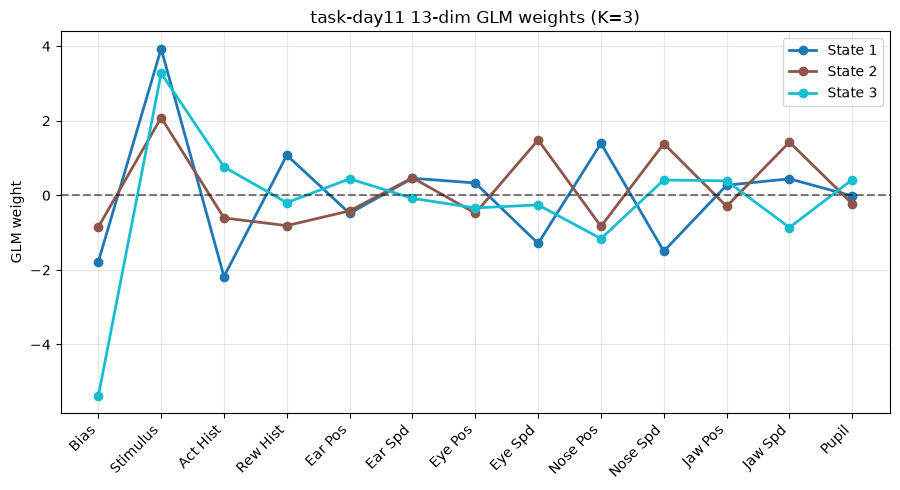

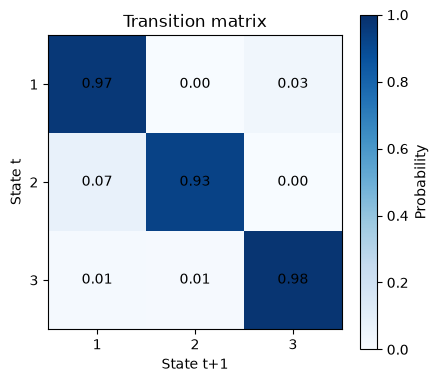

[[0.965 0.    0.035]
 [0.074 0.926 0.   ]
 [0.013 0.01  0.977]]


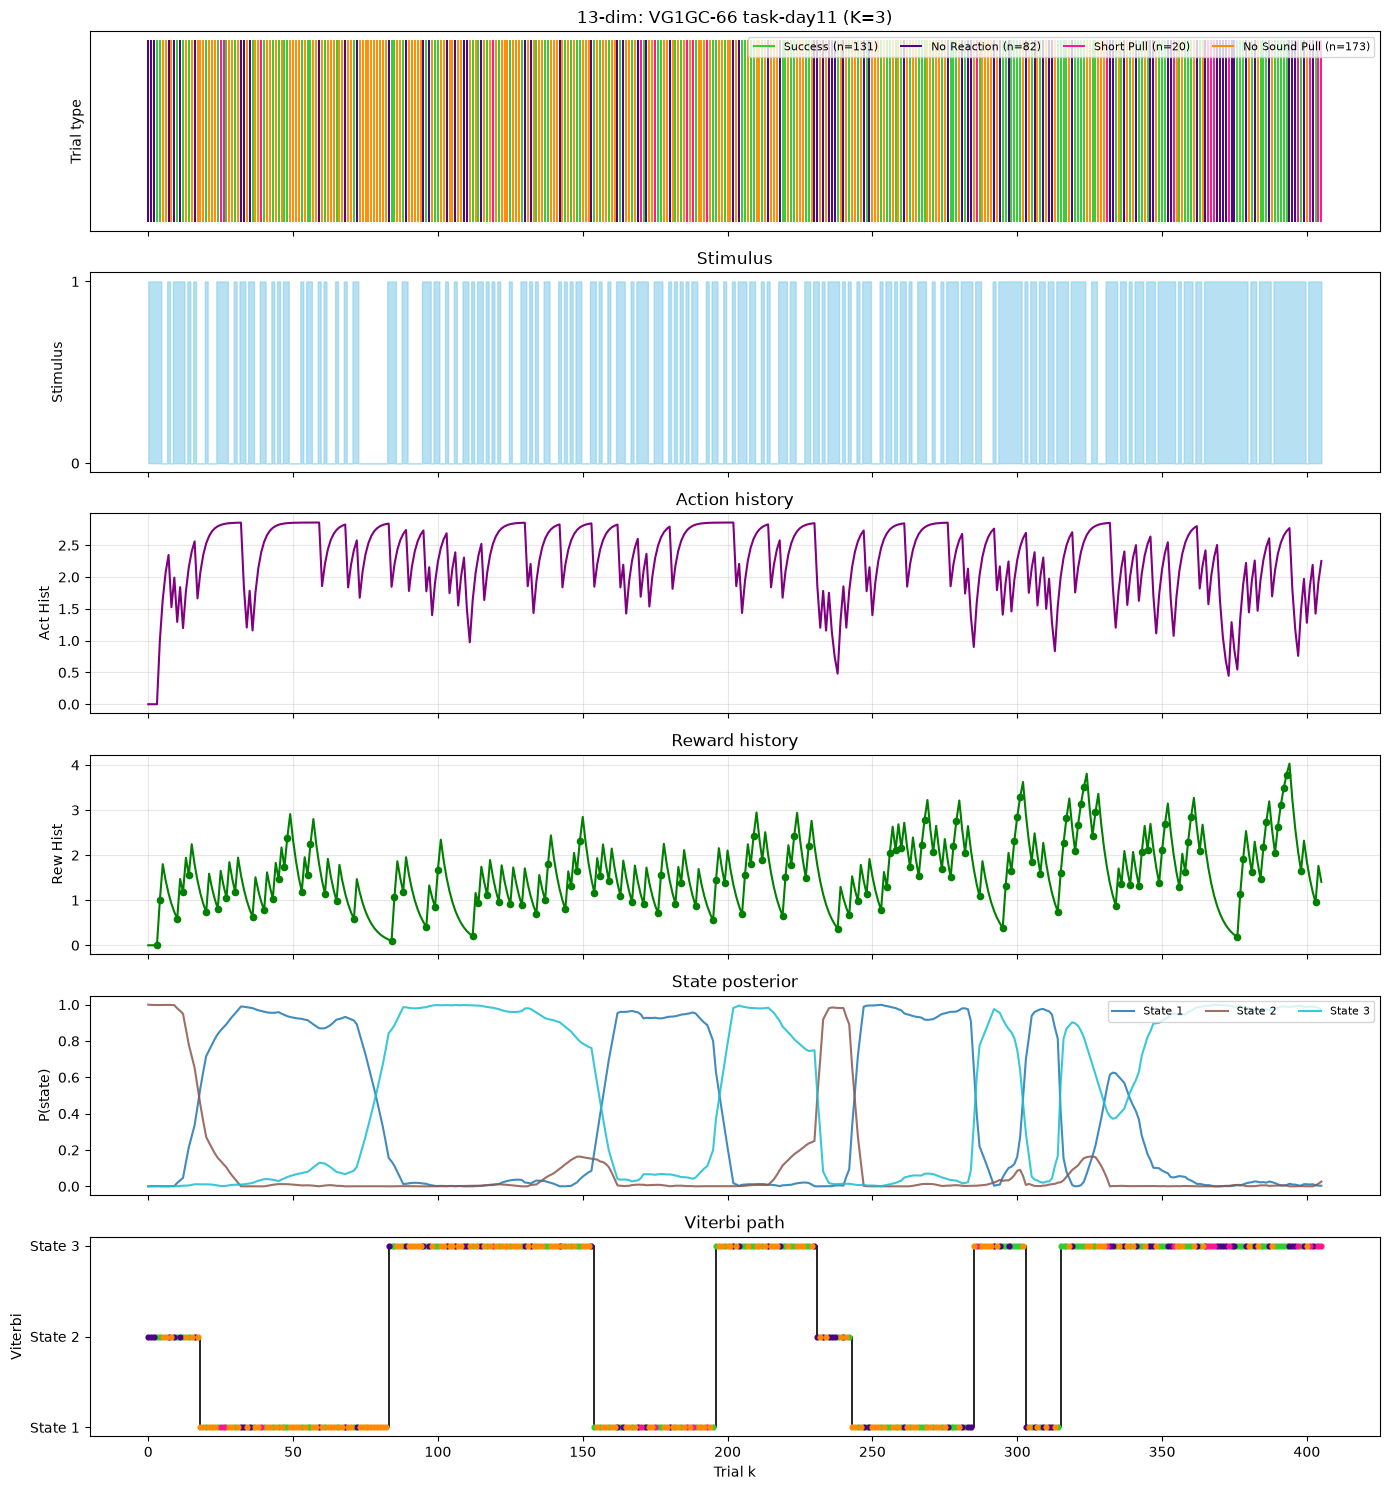

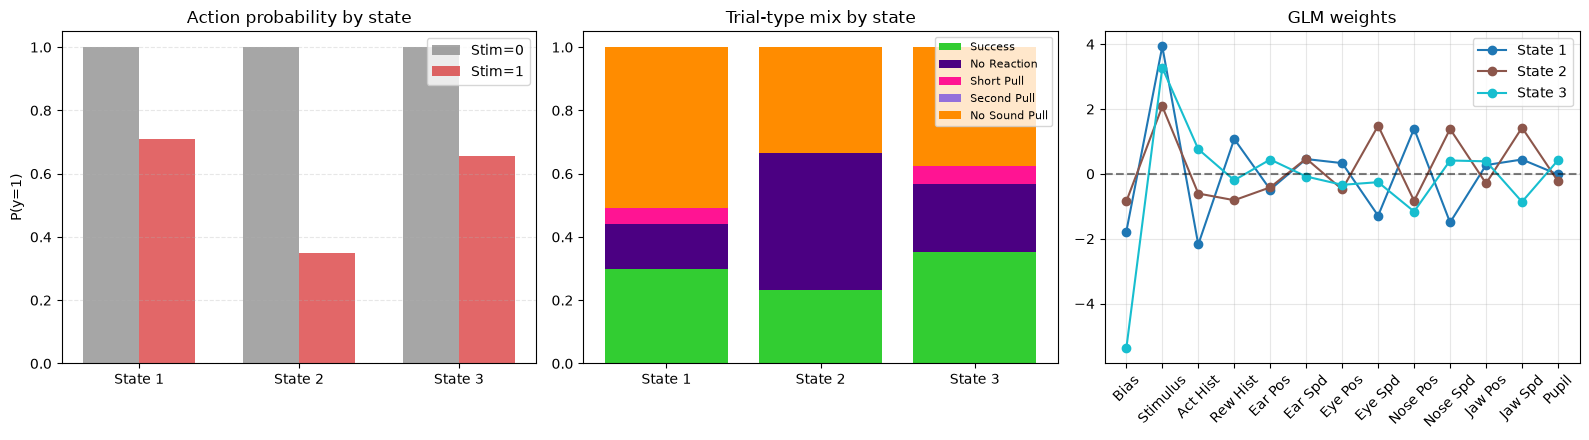

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.71
State 2 | Stim=0: 1.00  Stim=1: 0.35
State 3 | Stim=0: 1.00  Stim=1: 0.66
Viterbi occupancy: [161  30 215]

task-day12 (n=393 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-190.12


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-191.78


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-191.41
Best log_prob=-190.12


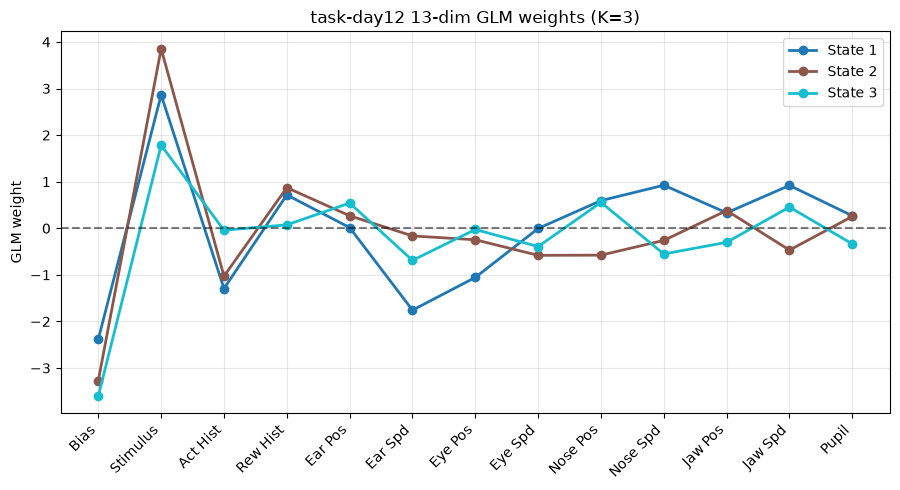

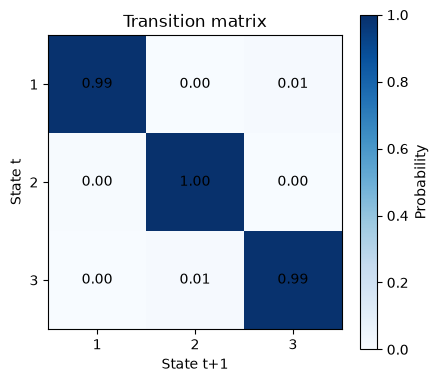

[[0.989 0.    0.011]
 [0.005 0.995 0.   ]
 [0.    0.012 0.988]]


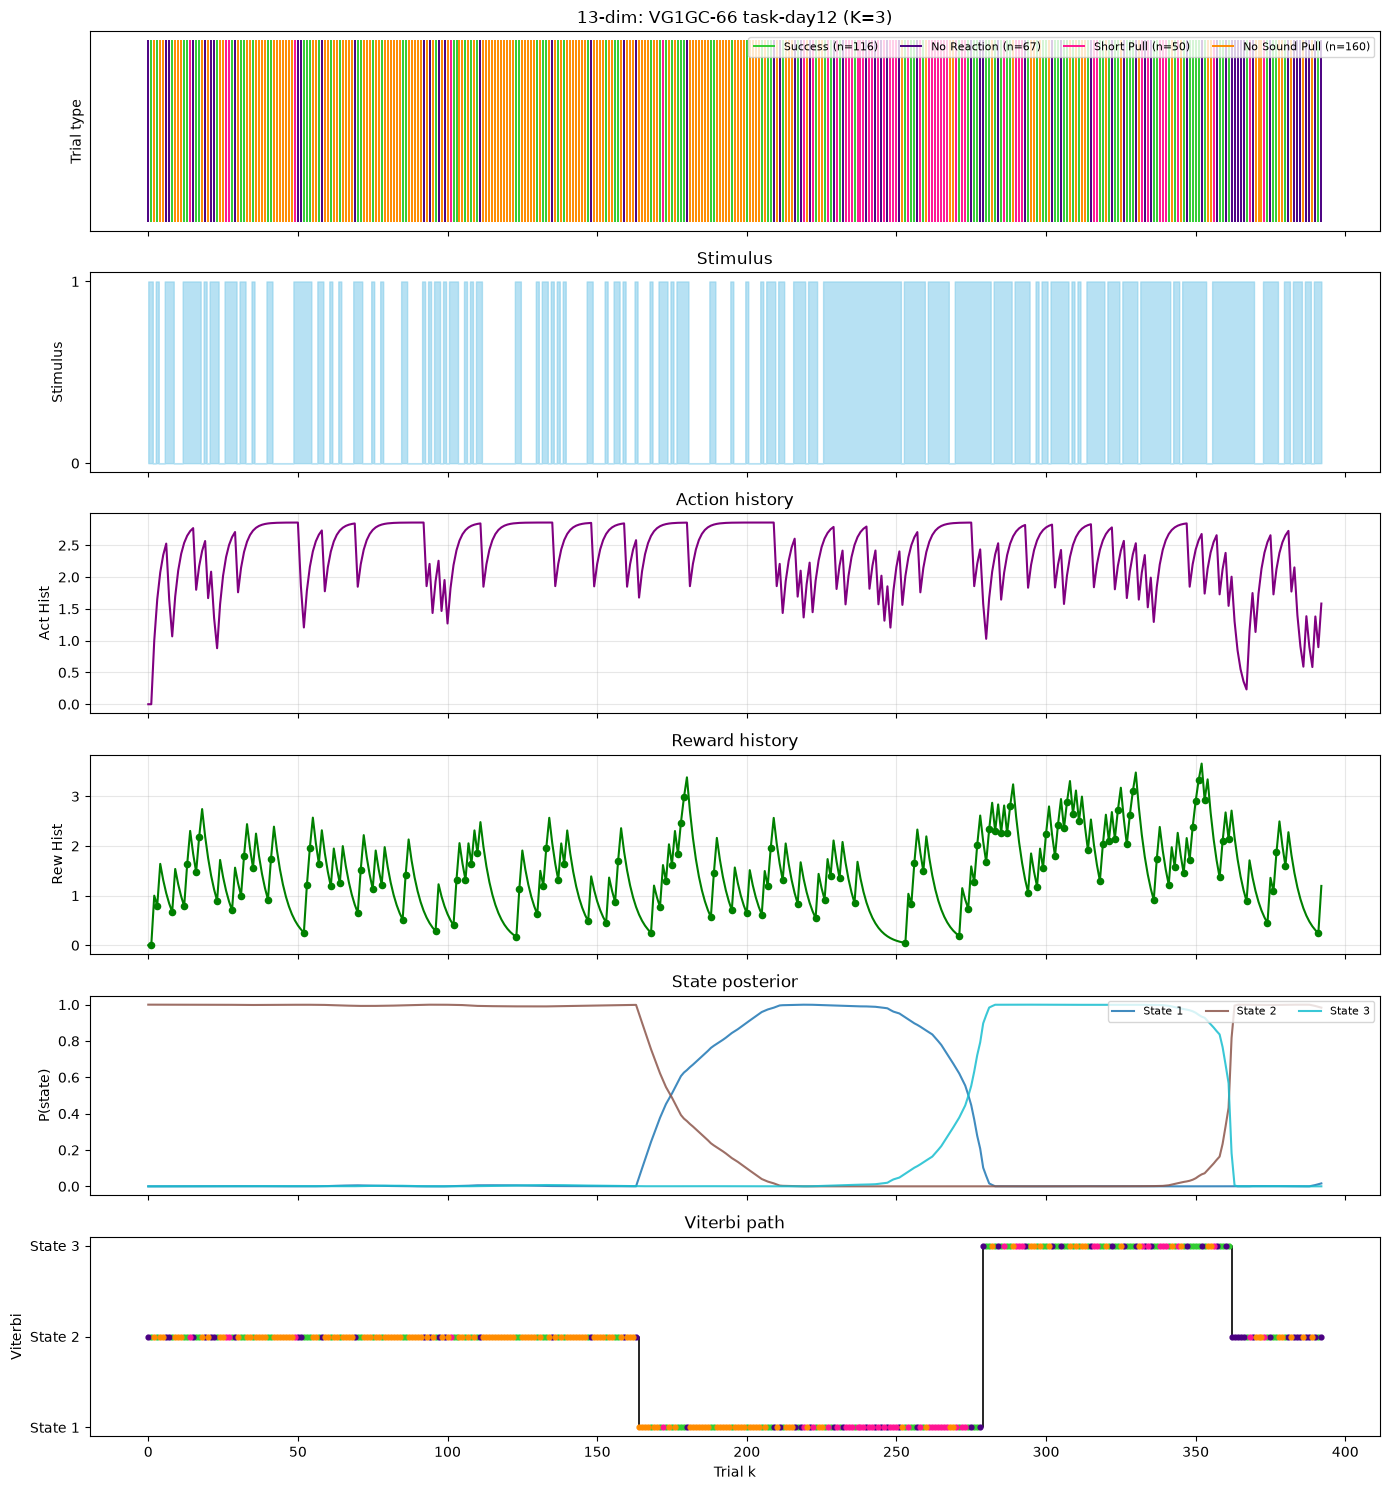

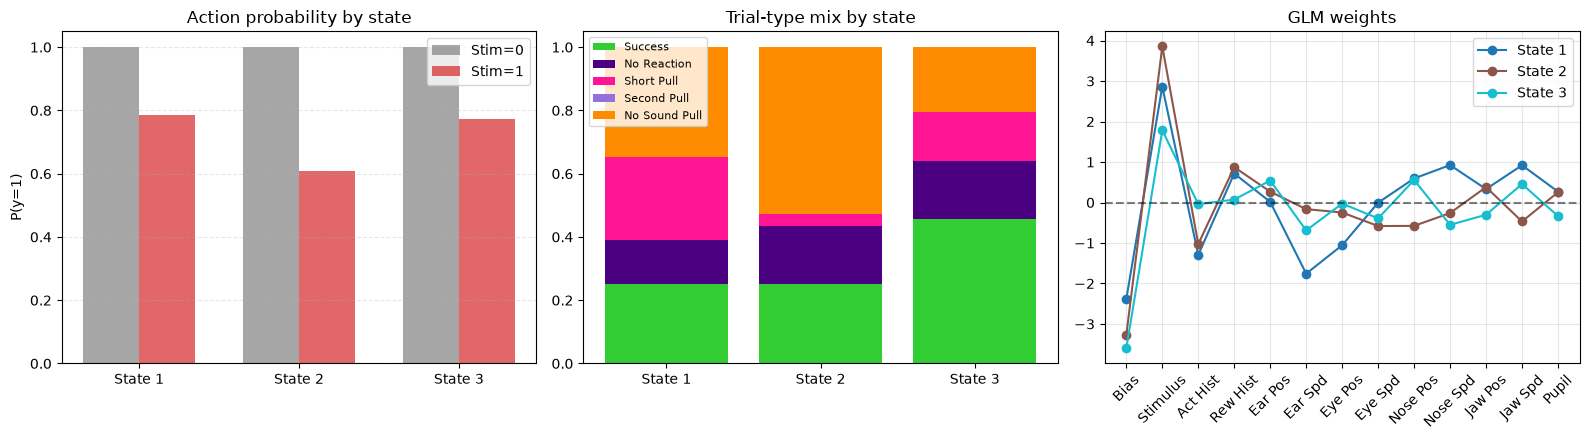

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.79
State 2 | Stim=0: 1.00  Stim=1: 0.61
State 3 | Stim=0: 1.00  Stim=1: 0.77
Viterbi occupancy: [115 195  83]

task-day13 (n=509 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-130.22


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-128.70


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-129.92
Best log_prob=-128.70


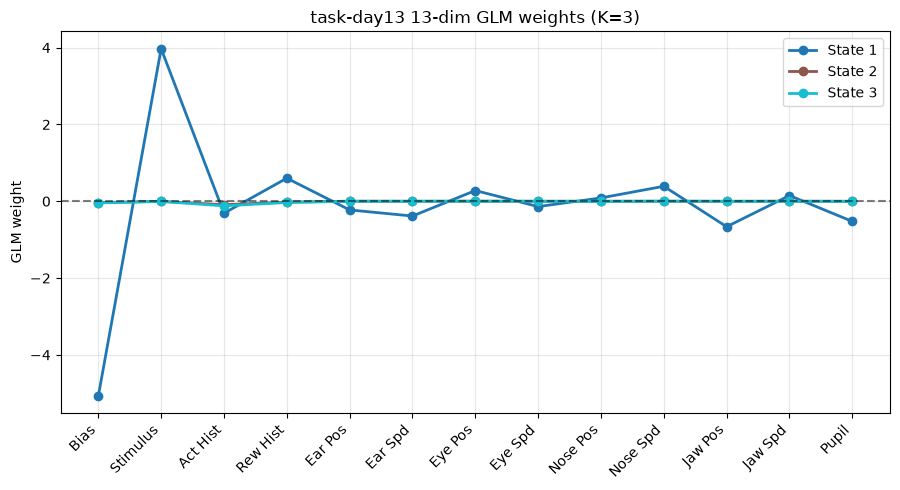

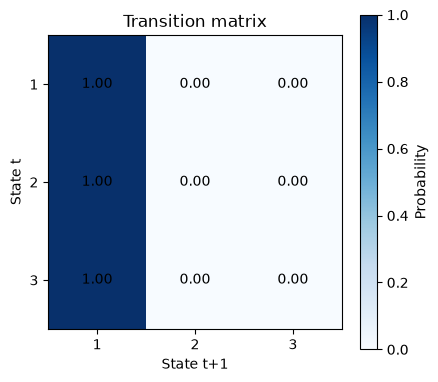

[[1.    0.    0.   ]
 [0.999 0.001 0.   ]
 [1.    0.    0.   ]]


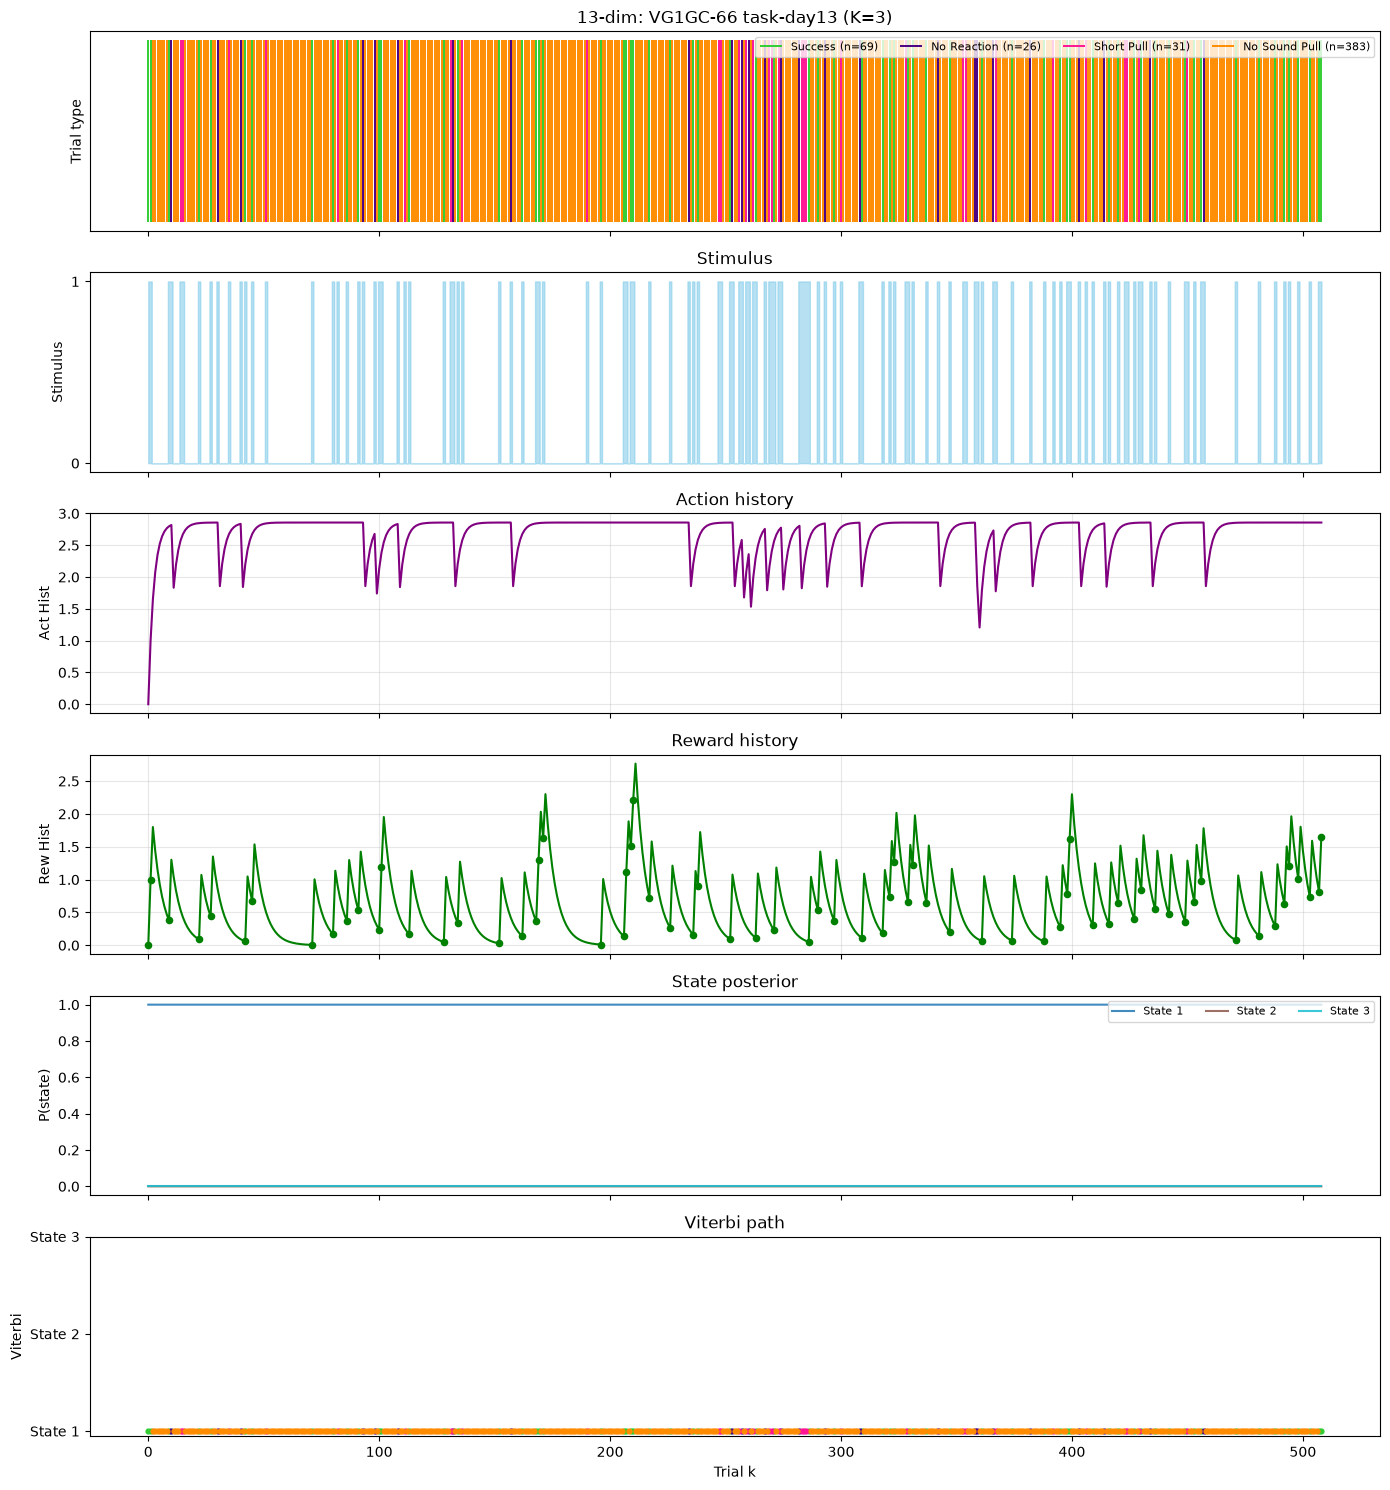

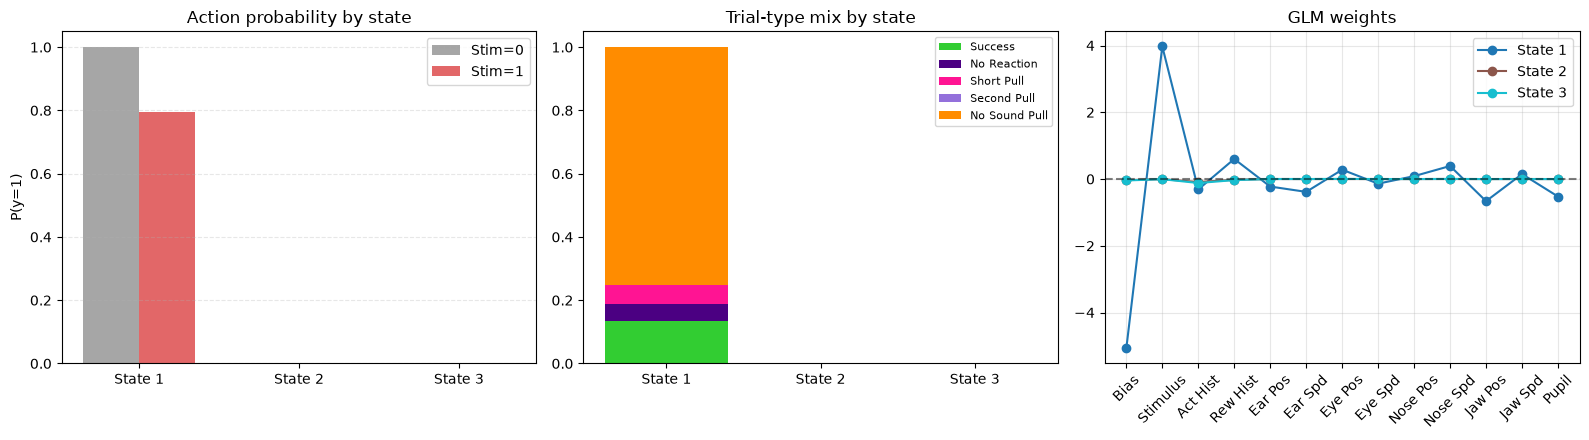

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.79
State 2 | Stim=0: 0.00  Stim=1: 0.00
State 3 | Stim=0: 0.00  Stim=1: 0.00
Viterbi occupancy: [509   0   0]

task-day14 (n=393 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-165.61


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-166.38


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-166.11
Best log_prob=-165.61


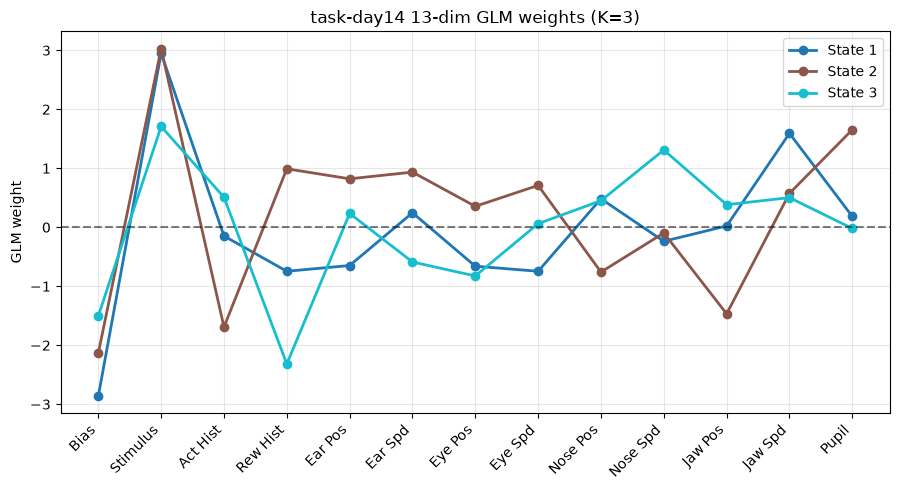

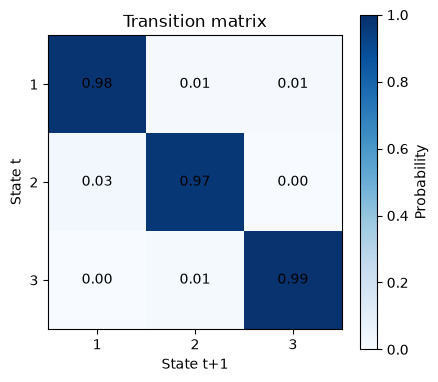

[[0.983 0.009 0.008]
 [0.028 0.972 0.   ]
 [0.    0.014 0.986]]


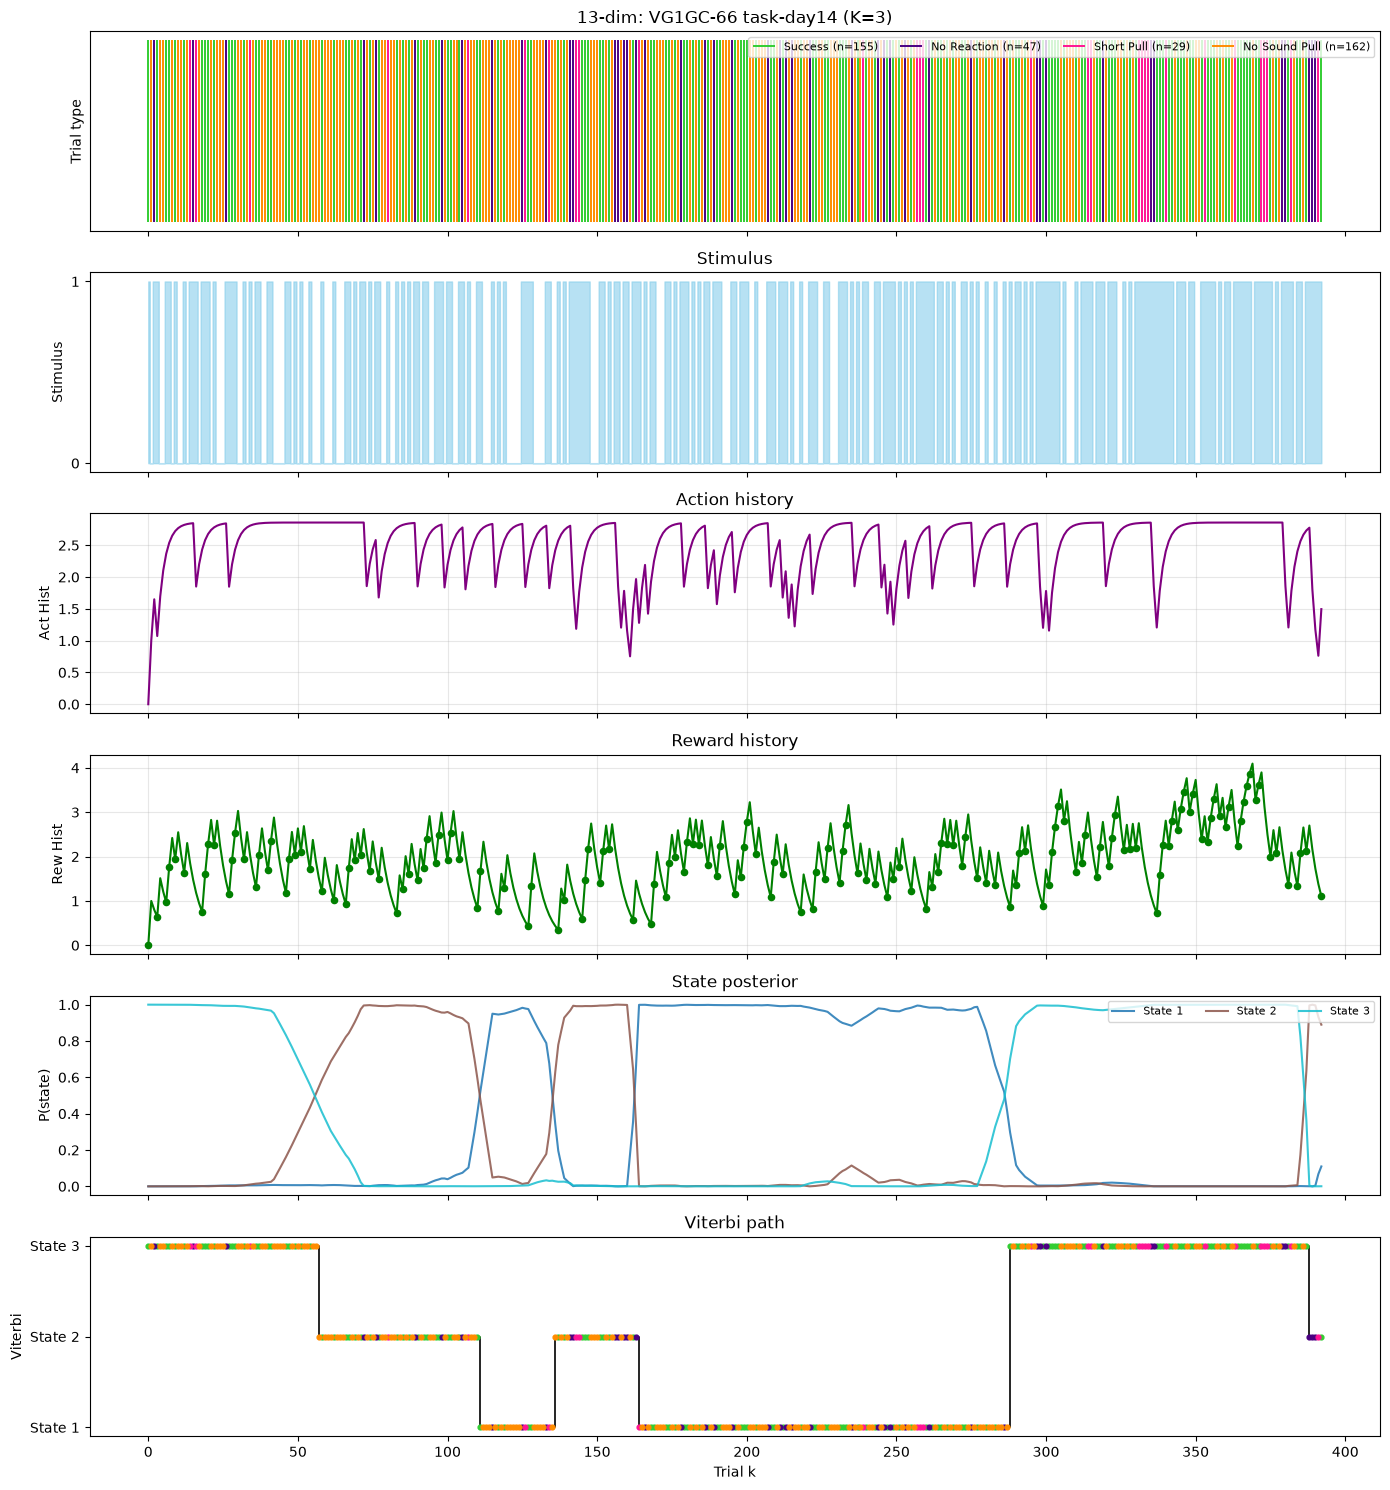

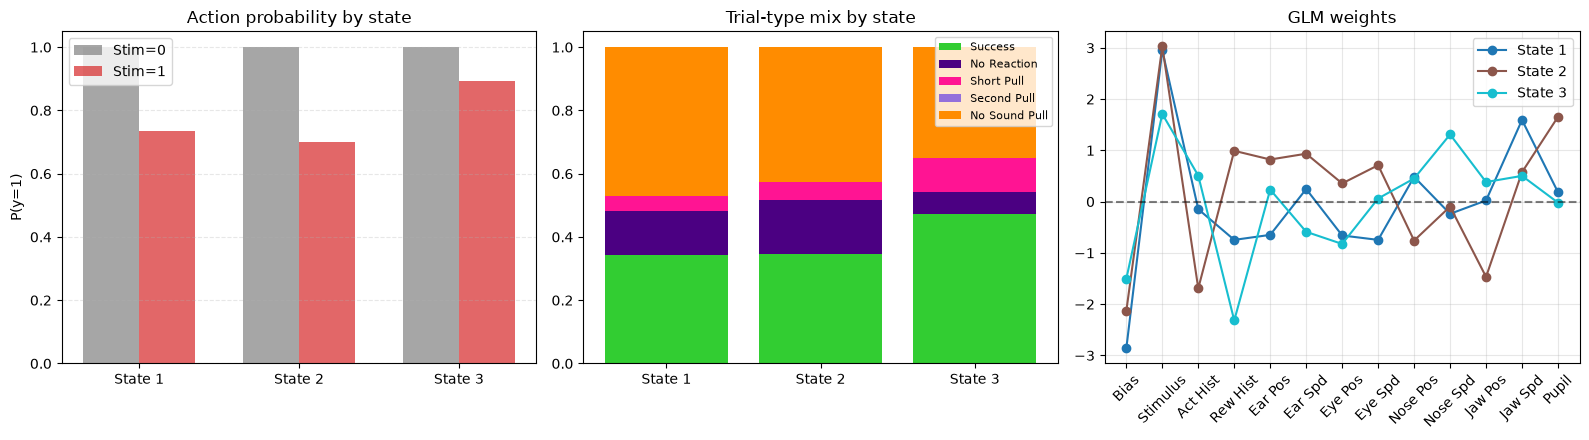

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.73
State 2 | Stim=0: 1.00  Stim=1: 0.70
State 3 | Stim=0: 1.00  Stim=1: 0.89
Viterbi occupancy: [149  87 157]

task-day15 (n=498 trials), 13-dim K=3
Training GLM-HMM K=3 M=13 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-158.78


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-155.07


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-155.62
Best log_prob=-155.07


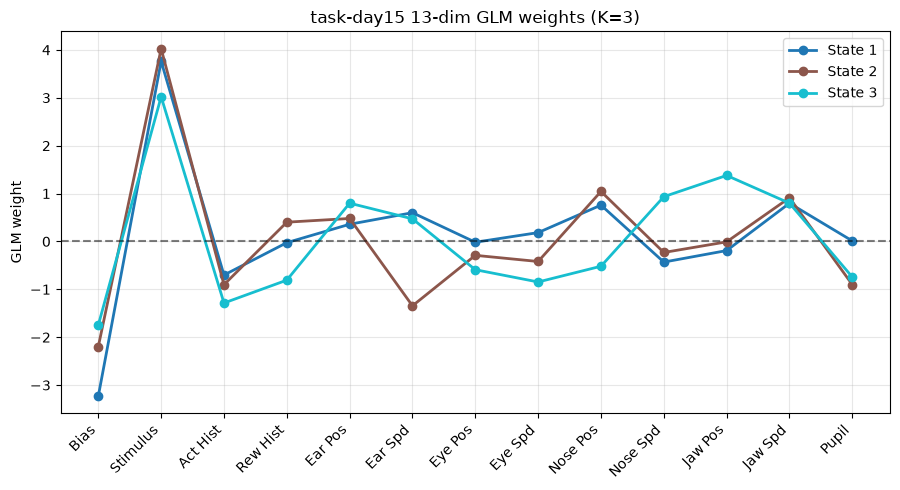

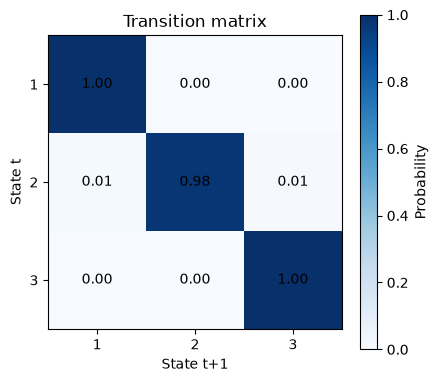

[[0.995 0.005 0.   ]
 [0.014 0.975 0.011]
 [0.    0.    1.   ]]


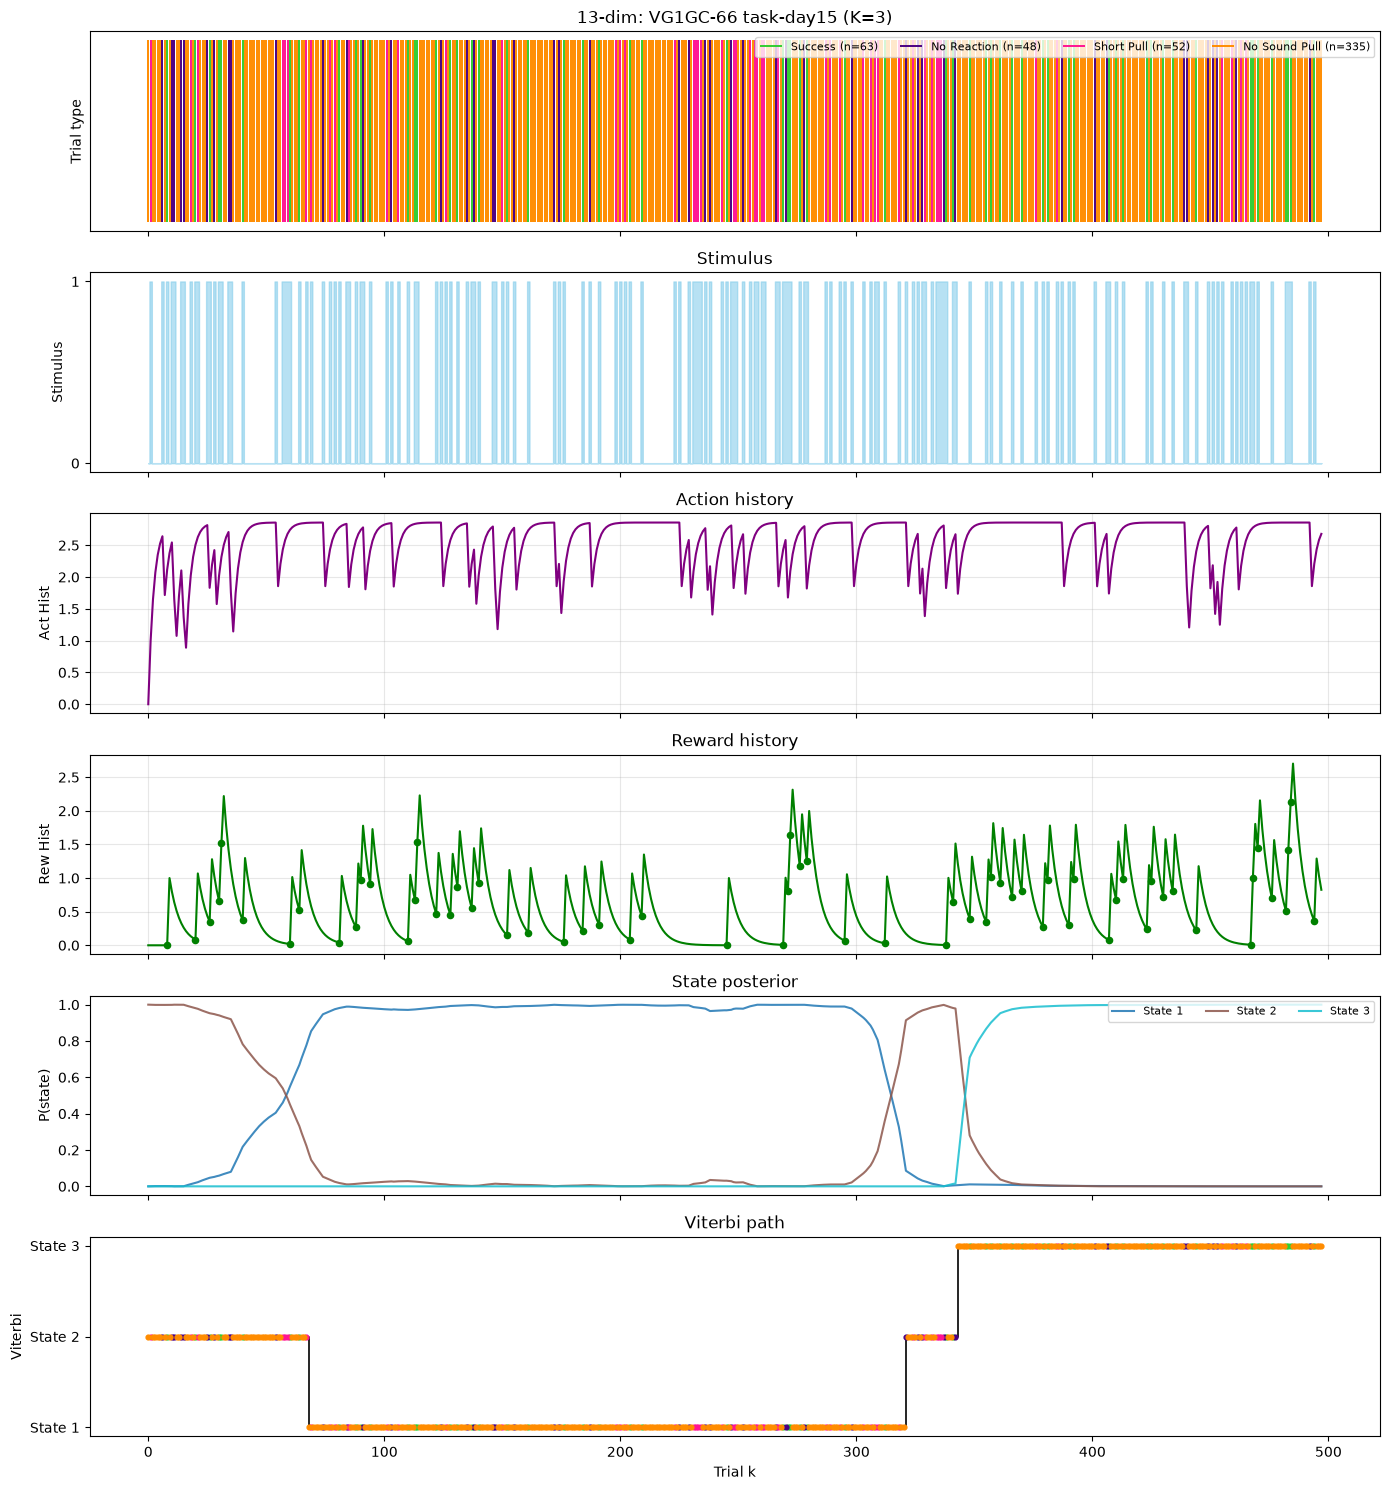

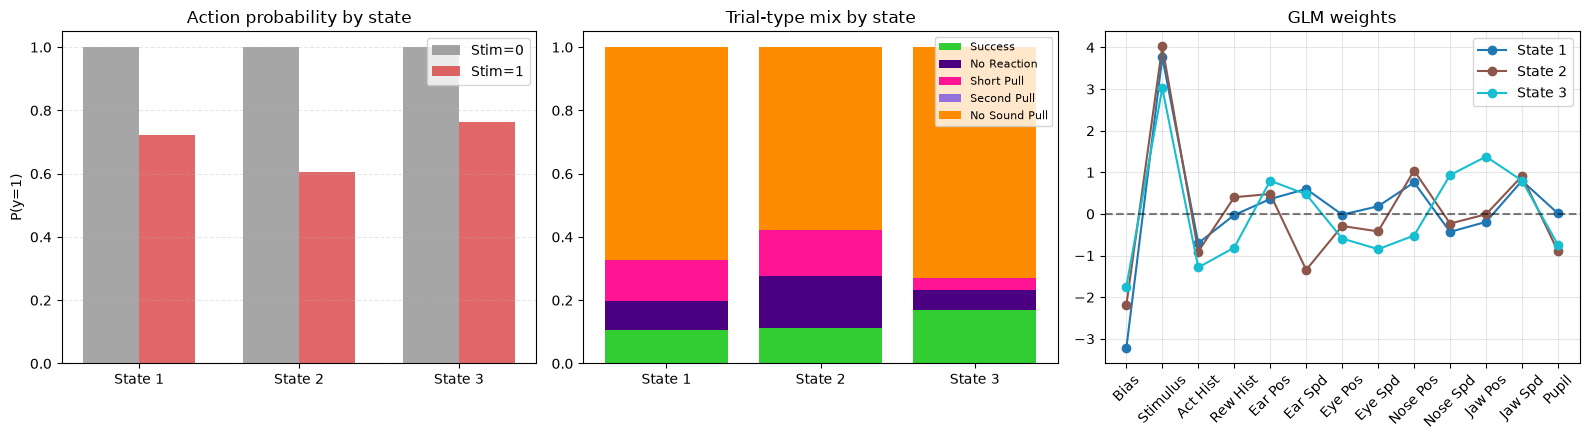

--- P(action | stim, state) ---
State 1 | Stim=0: 1.00  Stim=1: 0.72
State 2 | Stim=0: 1.00  Stim=1: 0.61
State 3 | Stim=0: 1.00  Stim=1: 0.76
Viterbi occupancy: [253  90 155]


In [7]:
models13 = {}
for i in face_idx:
    day = dataset["task_days"][i]
    y = dataset["ys"][i]
    x = dataset["xs13"][i]
    day_trials = dataset["trials"][dataset["trials"]["task_day"] == day]

    print(f"\n{'='*80}\n{day} (n={len(y)} trials), 13-dim K={NUM_STATES_B}\n{'='*80}")

    # 学習（日ごとに独立、K=3固定）
    model, lls, ll = v4.train_glmhmm_map(
        [y], [x],
        num_states=NUM_STATES_B,
        prior_sigma=PRIOR_SIGMA,
        num_iters=NUM_ITERS,
        seeds=SEEDS,
    )
    models13[day] = {"model": model, "lls": lls, "ll": ll, "y": y, "x": x}

    # GLM weights / transition matrix
    v4.plot_glm_weights(model, FACE_NAMES, title=f"{day} 13-dim GLM weights (K={NUM_STATES_B})")
    trans = v4.plot_transition_matrix(model)
    print(np.round(trans, 3))

    # trial type / stimulus / action hist / reward hist / state posterior / viterbi path をまとめて表示
    v4.plot_day_panel(
        model, day_trials, y, x,
        title=f"13-dim: {MOUSE_ID} {day} (K={NUM_STATES_B})",
    )

    # action probability by state / trial-type mix by state
    decoded = v4.attach_decoded_states(day_trials, *v4.decode_states(model, [y], [x]))
    v4.plot_state_behavior(model, decoded, FACE_NAMES)

    occ = np.bincount(model.most_likely_states(y, input=x), minlength=model.K)
    print(f"Viterbi occupancy: {occ}")